# 🔬 Particle Detection & Classification Notebook
**Phase 1 — Module 1 & 4: Feasibility + Detection Methods**

---
### What this notebook does:
1. **Upload** your BMP images
2. **Preprocessing** — CLAHE + denoise (explained step by step)
3. **Method A** — Threshold + Contours *(fastest, baseline)*
4. **Method B** — Blob Detector (SimpleBlobDetector) *(good for round particles)*
5. **Method C** — Hough Circle Transform *(best for perfect circles)*
6. **Method D** — Watershed Segmentation *(best for touching/agglomerated particles)*
7. **Compare all 4 methods** side by side
8. **Classify** particles: Single vs Touching (الجزيئات الملتصقة)
9. **Parameter tuning guide** — what to change and why
10. **Final report** in Arabic & English

> Run cells **top to bottom**. Each cell has comments explaining every step and what to tune.


---
## ⚙️ Cell 1 — Install & Import Libraries

In [ ]:
# ─── Install libraries ───
# opencv: image processing | matplotlib: visualization | numpy: math | pandas: tables
!pip install opencv-python-headless matplotlib numpy pandas scikit-image -q

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage import morphology as skmorph
from scipy import ndimage as ndi
import os, re, warnings
from google.colab import files
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

# ─── Plot settings ───
plt.rcParams['figure.dpi']      = 120
plt.rcParams['font.family']     = 'monospace'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅ All libraries loaded.')
print('📌 Image info: particles are WHITE on BLACK background, stored as BMP.')
print('   Mean pixel brightness is very low (~10/255) — CLAHE will fix this automatically.')

# ─── Physical scale — UPDATE if FOV changes ───
FOV_WIDTH_MM   = 30.0    # 🔧 Actual field of view width in mm (from client: 30mm)
IMAGE_WIDTH_PX = 2048    # Camera resolution width
MM_PER_PX      = FOV_WIDTH_MM / IMAGE_WIDTH_PX   # = 0.01465 mm/px = 14.65 µm/px
UM_PER_PX      = MM_PER_PX * 1000                # micrometers per pixel

print(f'✅ Physical scale: {MM_PER_PX*1000:.2f} µm/px  |  FOV = {FOV_WIDTH_MM}mm / {IMAGE_WIDTH_PX}px')
print(f'   1mm particle = {1.0/MM_PER_PX:.0f} px diameter')
print(f'   ±10µm accuracy = ±{0.010/MM_PER_PX:.2f} px  (sub-pixel Gaussian fitting needed)')
print(f'   ±20µm accuracy = ±{0.020/MM_PER_PX:.2f} px  (achievable)')

# ─── Cell Execution Tracker ───
# This dict tracks which cells have been run successfully
# At the end (last cell) we print a full summary of what was applied
CELL_STATUS = {
    'C1_libraries':        False,
    'C2_upload':           False,
    'C3_preprocessing':    False,
    'C4_method_A':         False,
    'C5_method_B':         False,
    'C6_method_C':         False,
    'C7_method_D':         False,
    'C8_comparison':       False,
    'C9_classification':   False,
    'C10_shape_metrics':   False,
    'C10b_accuracy':       False,
    'C_avg_size_per_sample': False,
    'C11_report':          False,
}
CELL_NOTES = {}  # stores key results per cell
print('✅ Cell tracker initialized.')
CELL_STATUS['C1_libraries'] = True


✅ All libraries loaded.
📌 Image info: particles are WHITE on BLACK background, stored as BMP.
   Mean pixel brightness is very low (~10/255) — CLAHE will fix this automatically.
✅ Physical scale: 14.65 µm/px  |  FOV = 30.0mm / 2048px
   1mm particle = 68 px diameter
   ±10µm accuracy = ±0.68 px  (sub-pixel Gaussian fitting needed)
   ±20µm accuracy = ±1.37 px  (achievable)
✅ Cell tracker initialized.


---
## 📁 Cell 2 — Upload Images

In [ ]:
# ─── Upload BMP files ───
# A file picker will appear — select ALL your .bmp files at once.

print('📂 Select your BMP images...')
uploaded = files.upload()

UPLOAD_DIR = '/content/samples'
os.makedirs(UPLOAD_DIR, exist_ok=True)

for fname, data in uploaded.items():
    with open(os.path.join(UPLOAD_DIR, fname), 'wb') as f:
        f.write(data)

# ─── Build sorted list ───
IMAGE_FILES = sorted([
    os.path.join(UPLOAD_DIR, f)
    for f in os.listdir(UPLOAD_DIR)
    if f.lower().endswith(('.bmp', '.png', '.jpg', '.tiff'))
])

print(f'\n✅ {len(IMAGE_FILES)} images ready:')
for i, p in enumerate(IMAGE_FILES):
    nums = re.findall(r'\d+', os.path.basename(p))
    frame = nums[-1] if nums else str(i)
    sz = os.path.getsize(p) / (1024*1024)
    print(f'  [{i:02d}] Frame {frame:<8} {sz:.1f} MB')

CELL_STATUS['C2_upload'] = True
CELL_NOTES['C2_upload'] = f'{len(IMAGE_FILES)} images loaded'


📂 Select your BMP images...



✅ 30 images ready:
  [00] Frame 140      3.0 MB
  [01] Frame 141      3.0 MB
  [02] Frame 142      3.0 MB
  [03] Frame 143      3.0 MB
  [04] Frame 144      3.0 MB
  [05] Frame 145      3.0 MB
  [06] Frame 146      3.0 MB
  [07] Frame 147      3.0 MB
  [08] Frame 148      3.0 MB
  [09] Frame 149      3.0 MB
  [10] Frame 150      3.0 MB
  [11] Frame 151      3.0 MB
  [12] Frame 152      3.0 MB
  [13] Frame 153      3.0 MB
  [14] Frame 154      3.0 MB
  [15] Frame 155      3.0 MB
  [16] Frame 156      3.0 MB
  [17] Frame 157      3.0 MB
  [18] Frame 158      3.0 MB
  [19] Frame 159      3.0 MB
  [20] Frame 160      3.0 MB
  [21] Frame 161      3.0 MB
  [22] Frame 162      3.0 MB
  [23] Frame 163      3.0 MB
  [24] Frame 164      3.0 MB
  [25] Frame 165      3.0 MB
  [26] Frame 166      3.0 MB
  [27] Frame 167      3.0 MB
  [28] Frame 168      3.0 MB
  [29] Frame 169      3.0 MB


---
## 🎛️ Cell 3 — Preprocessing Pipeline
> **Run this once — all detection methods below depend on it.**

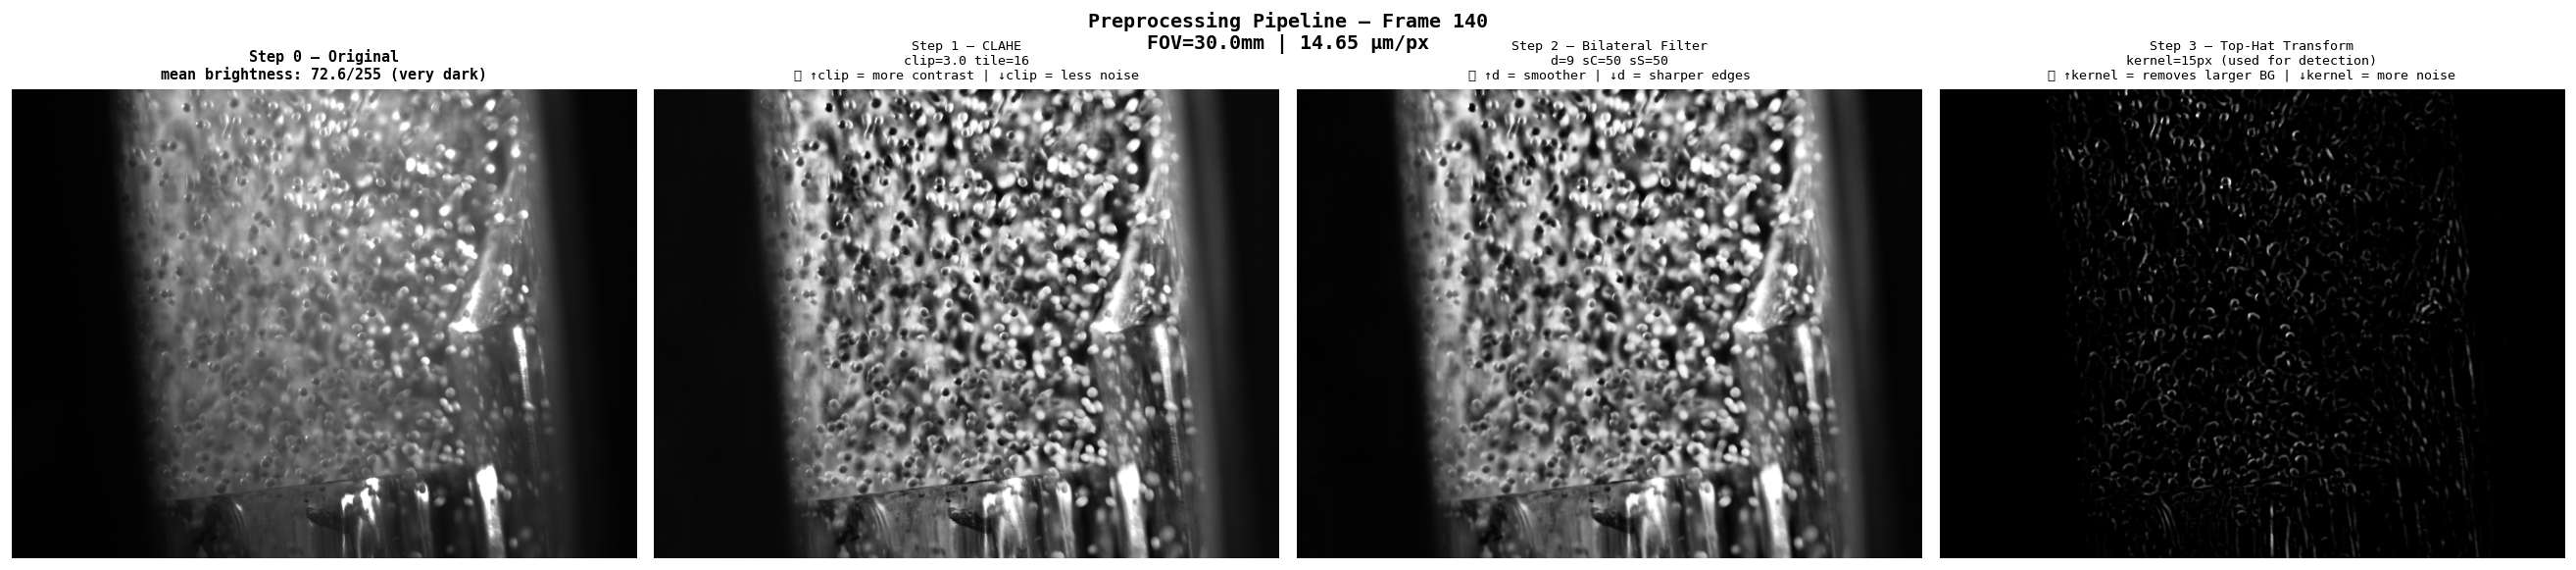


📊 Sharpness (Laplacian variance):
   Original:     78.1  (raw — dark image score is misleadingly low)
   After CLAHE:  493.9  (true sharpness)
   After Top-Hat:15.1


IndexError: index 16 is out of bounds for axis 0 with size 16

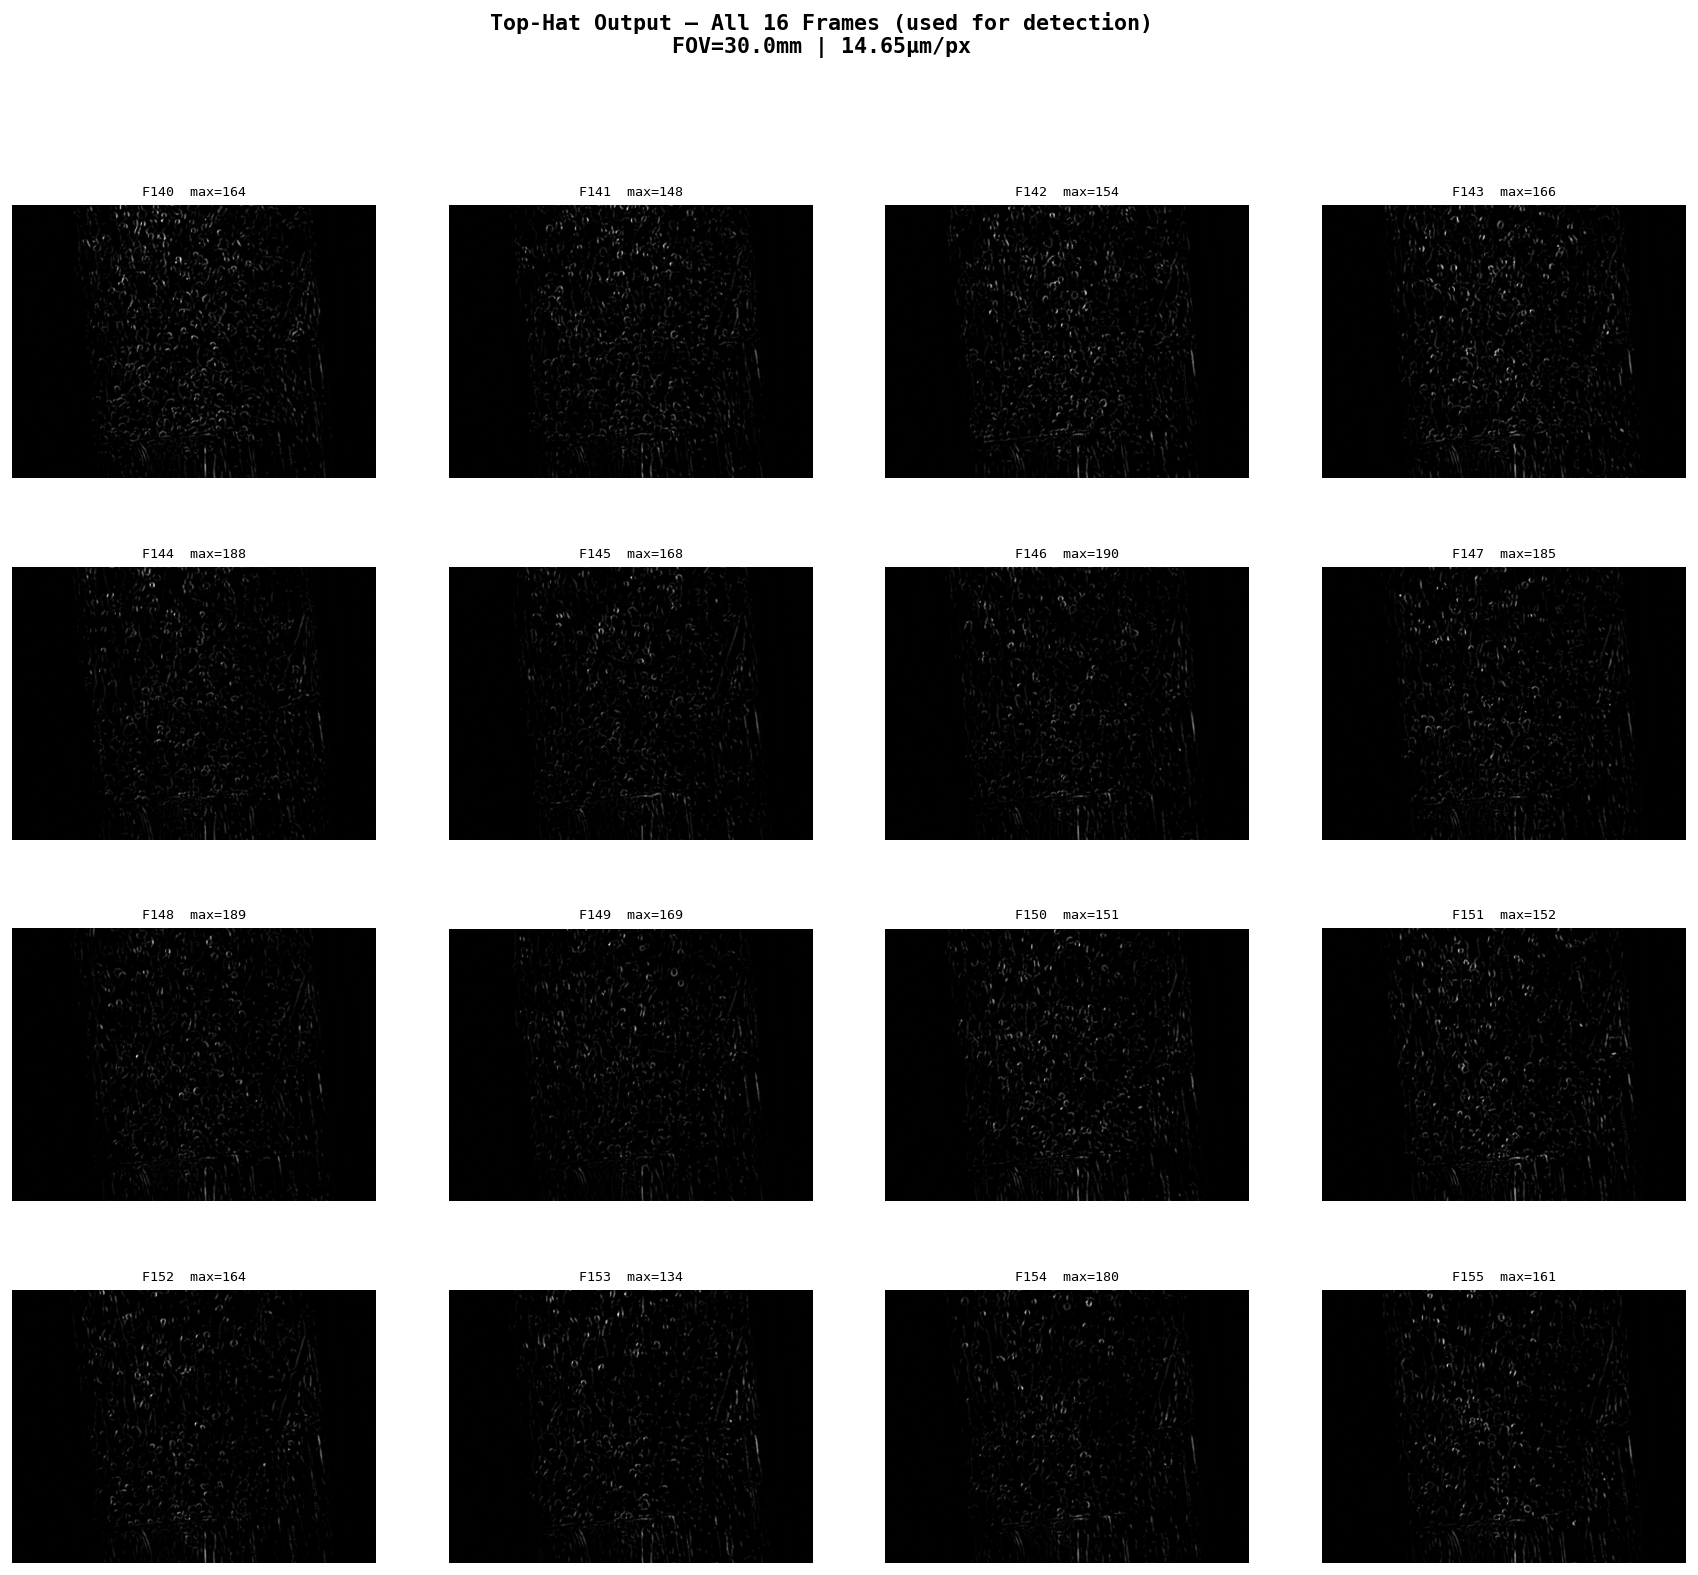

In [ ]:
import math

# ─── Visualize pipeline on one frame ───
TARGET_IDX = 0
gray, enh, bil, tophat = advanced_preprocess(IMAGE_FILES[TARGET_IDX])

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(f'Preprocessing Pipeline — Frame {TARGET_IDX}\nFOV={FOV_WIDTH_MM}mm | {UM_PER_PX:.2f} µm/px', fontsize=12, fontweight='bold')

axes[0].imshow(gray, cmap='gray'); axes[0].set_title('Step 0 — Original', fontsize=9); axes[0].axis('off')
axes[1].imshow(enh, cmap='gray'); axes[1].set_title('Step 1 — CLAHE', fontsize=8); axes[1].axis('off')
axes[2].imshow(bil, cmap='gray'); axes[2].set_title('Step 2 — Bilateral', fontsize=8); axes[2].axis('off')
axes[3].imshow(tophat, cmap='gray'); axes[3].set_title('Step 3 — Top-Hat', fontsize=8); axes[3].axis('off')
plt.show()

# ── Show ALL uploaded frames ──
n_imgs = len(IMAGE_FILES)
cols = 4
rows = math.ceil(n_imgs / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3.5))
fig.suptitle(f'Top-Hat Output — All {n_imgs} Frames', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, fpath in enumerate(IMAGE_FILES):
    _, _, _, th = advanced_preprocess(fpath)
    nums = re.findall(r'\d+', os.path.basename(fpath))
    axes[i].imshow(th, cmap='gray')
    axes[i].set_title(f'F{nums[-1] if nums else i} max={th.max()}', fontsize=8)
    axes[i].axis('off')

for j in range(i + 1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()

CELL_STATUS['C3_preprocessing'] = True

---
## 🅰️ Cell 4 — Method A: Threshold + Contours
> **Fastest method. Best starting point. Works well when brightness is consistent.**

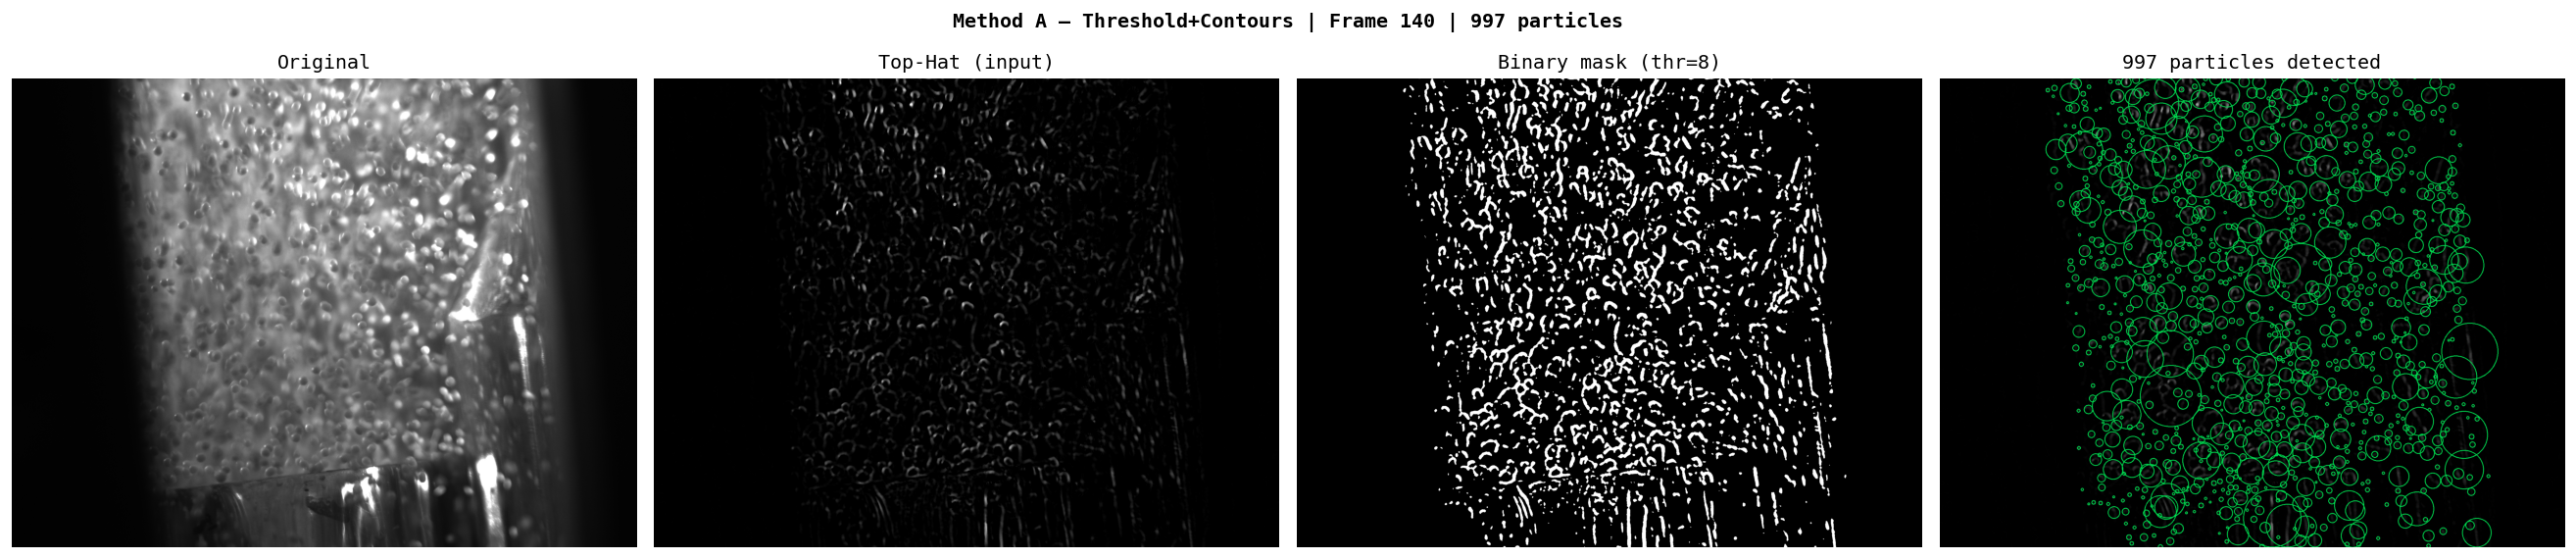

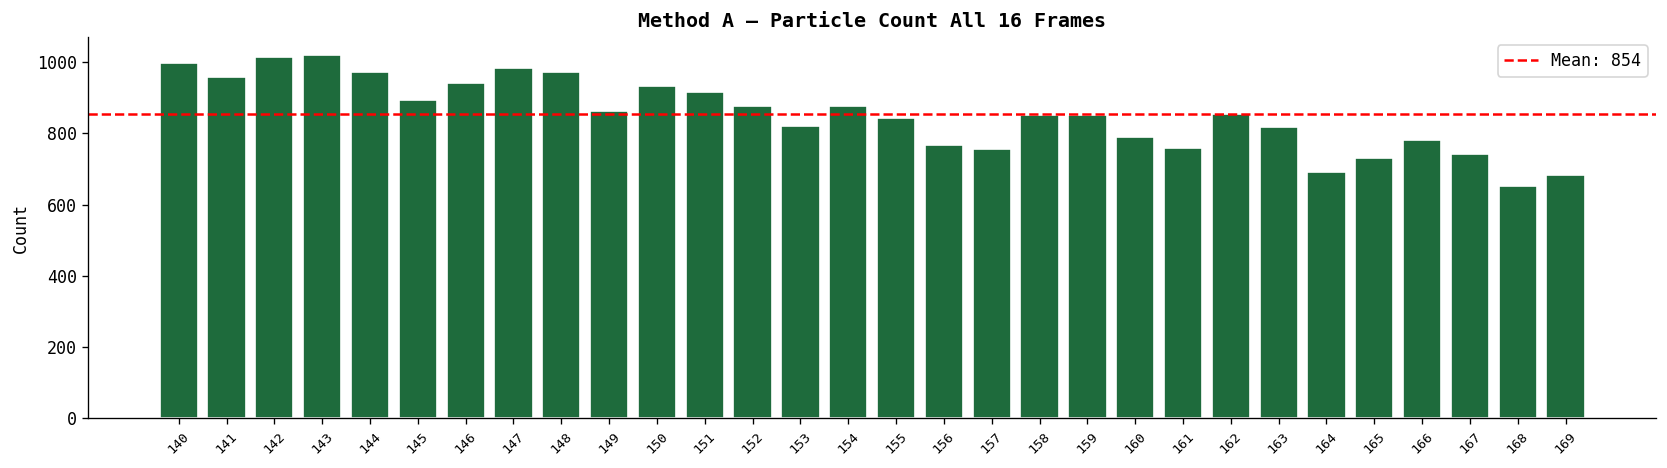

IndexError: index 16 is out of bounds for axis 0 with size 16

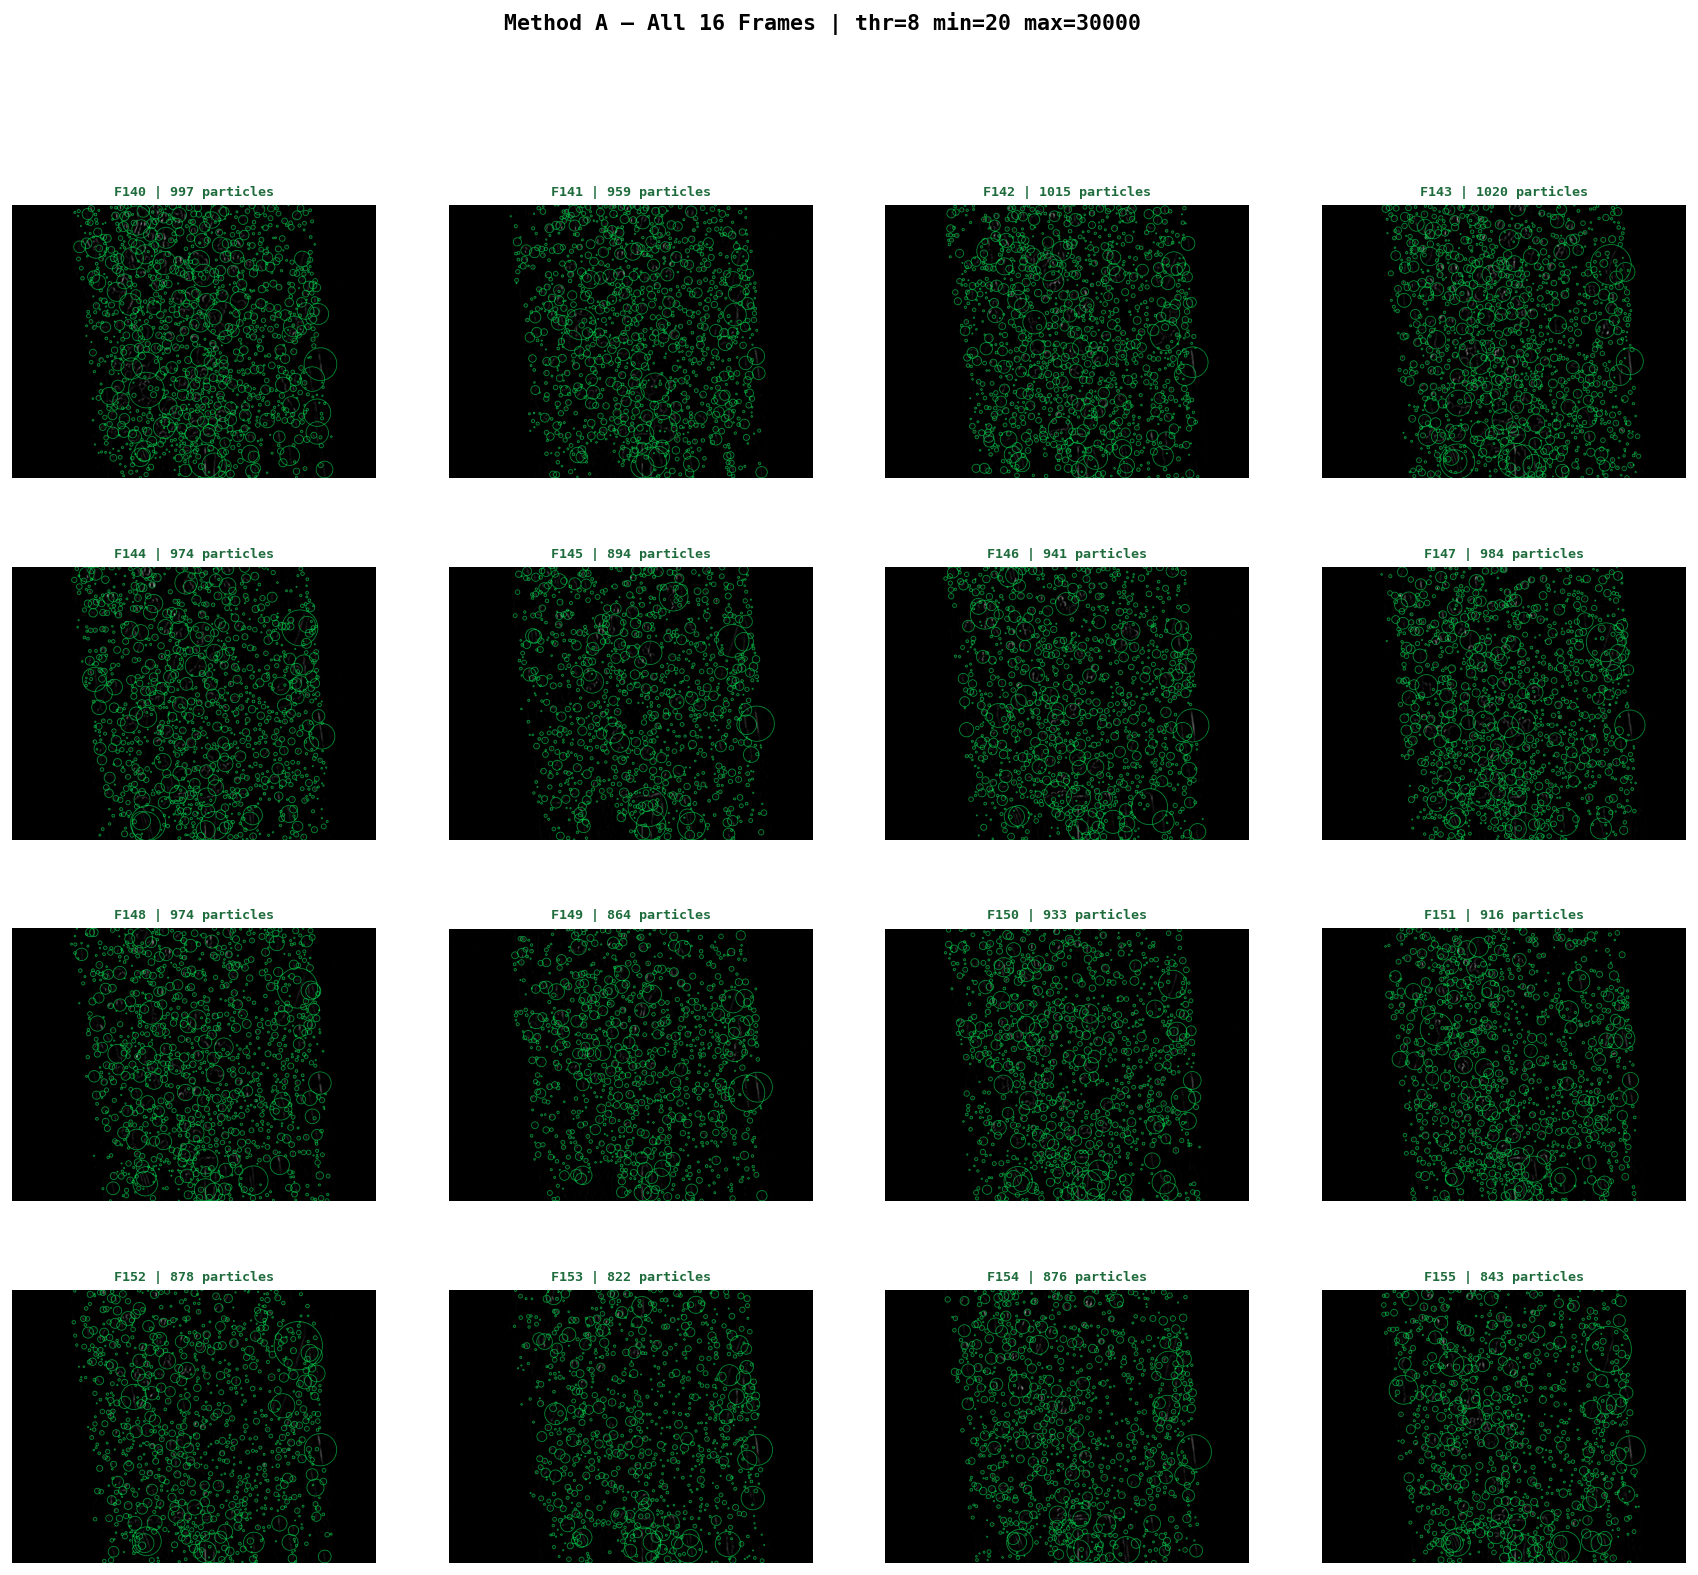

In [ ]:
# ... [Existing parameters same as before] ...

# ─── Grid all uploaded frames ───
n_imgs = len(IMAGE_FILES)
cols = 4
rows = math.ceil(n_imgs / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3.5))
fig.suptitle(f'Method A — All {n_imgs} Frames', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, fpath in enumerate(IMAGE_FILES):
    _, enh, _, p = method_A(fpath)
    vis2 = cv2.cvtColor(enh, cv2.COLOR_GRAY2RGB)
    for c in p:
        (x,y),r = cv2.minEnclosingCircle(c)
        cv2.circle(vis2,(int(x),int(y)),max(int(r),3),(0,220,80),2)
    nums = re.findall(r'\d+', os.path.basename(fpath))
    axes[i].imshow(vis2)
    axes[i].set_title(f'F{nums[-1] if nums else i} | {len(p)} particles', fontsize=8)
    axes[i].axis('off')

for j in range(i + 1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()

CELL_STATUS['C4_method_A'] = True

---
## 🅱️ Cell 5 — Method B: SimpleBlobDetector
> **Best for circular blobs of known size range. Filters by shape + size simultaneously.**

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# METHOD B PARAMETERS
# ═══════════════════════════════════════════════════════════════════
B_MIN_THRESHOLD    = 20    # 🔧 Start of threshold sweep (lower = detect dimmer blobs)
B_MAX_THRESHOLD    = 200   # 🔧 End of threshold sweep
B_MIN_AREA         = 100   # 🔧 Minimum blob area (pixels²) — filters noise
B_MAX_AREA         = 8000  # 🔧 Maximum blob area — filters large agglomerations
B_MIN_CIRCULARITY  = 0.4   # 🔧 Shape filter: 1.0 = perfect circle, 0.0 = any shape
                            #    Lower → detects elongated/touching blobs too
                            #    Higher → only detects round individual particles
B_MIN_CONVEXITY    = 0.6   # 🔧 Convexity: 1.0 = fully convex (no dents), lower allows dented shapes
B_MIN_INERTIA      = 0.3   # 🔧 Elongation: 1.0 = circle, 0.0 = line
# ═══════════════════════════════════════════════════════════════════

def method_B(fpath):
    """
    Method B: SimpleBlobDetector
    OpenCV's built-in blob detector. Scans multiple thresholds and finds
    stable circular blobs. Filters simultaneously by: area, circularity,
    convexity, and inertia ratio.
    Good at: rejecting non-circular noise, finding clean isolated particles.
    Limitation: tends to miss touching particles (they look non-circular).
    """
    gray, enhanced, blurred = preprocess(fpath)

    params = cv2.SimpleBlobDetector_Params()

    # Threshold sweep — detector tries many threshold values and finds stable blobs
    params.minThreshold = B_MIN_THRESHOLD
    params.maxThreshold = B_MAX_THRESHOLD

    # Filter by area
    params.filterByArea        = True
    params.minArea             = B_MIN_AREA
    params.maxArea             = B_MAX_AREA

    # Filter by circularity (how round the blob is)
    params.filterByCircularity = True
    params.minCircularity      = B_MIN_CIRCULARITY

    # Filter by convexity (no major concave dents)
    params.filterByConvexity   = True
    params.minConvexity        = B_MIN_CONVEXITY

    # Filter by inertia (how elongated)
    params.filterByInertia     = True
    params.minInertiaRatio     = B_MIN_INERTIA

    # SimpleBlobDetector works on dark blobs — we invert since particles are bright
    inverted   = cv2.bitwise_not(blurred)
    detector   = cv2.SimpleBlobDetector_create(params)
    keypoints  = detector.detect(inverted)
    return gray, enhanced, keypoints

# ─── Visualize ───
TARGET_IDX = 0   # 🔧 Change frame

gray, enhanced, keypoints = method_B(IMAGE_FILES[TARGET_IDX])

vis = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
for kp in keypoints:
    x, y = int(kp.pt[0]), int(kp.pt[1])
    r    = max(int(kp.size / 2), 3)
    cv2.circle(vis, (x, y), r, (0, 180, 255), 2)  # blue circles

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
nums = re.findall(r'\d+', os.path.basename(IMAGE_FILES[TARGET_IDX]))
fig.suptitle(f'Method B — SimpleBlobDetector | Frame {nums[-1] if nums else TARGET_IDX} | {len(keypoints)} blobs',
             fontsize=12, fontweight='bold')

axes[0].imshow(cv2.bitwise_not(enhanced), cmap='gray')
axes[0].set_title('Inverted (detector input)\nblobs appear dark here'); axes[0].axis('off')

axes[1].imshow(vis)
axes[1].set_title(f'Detected blobs (blue)\n{len(keypoints)} found'); axes[1].axis('off')

# Size histogram
if keypoints:
    sizes = [kp.size for kp in keypoints]
    axes[2].hist(sizes, bins=20, color='#2E75B6', edgecolor='white', alpha=0.85)
    axes[2].axvline(np.mean(sizes), color='red', linestyle='--', label=f'Mean: {np.mean(sizes):.1f}px')
    axes[2].set_title('Blob Size Distribution'); axes[2].set_xlabel('Blob Diameter (px)'); axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'No blobs detected\nTry lowering B_MIN_CIRCULARITY\nor B_MIN_THRESHOLD',
                 ha='center', va='center', fontsize=11, color='red')
    axes[2].axis('off')
plt.tight_layout(); plt.show()

counts_B = []
for f in IMAGE_FILES:
    _, _, kps = method_B(f)
    counts_B.append(len(kps))

print(f'📊 Method B Results:')
print(f'   Avg blobs/frame: {np.mean(counts_B):.1f}')
print(f'   Min / Max:       {min(counts_B)} / {max(counts_B)}')
print(f'\n🔧 Tuning guide:')
print(f'   Detecting too few? → lower B_MIN_CIRCULARITY (e.g. 0.3) or B_MIN_THRESHOLD')
print(f'   Too many false blobs? → raise B_MIN_CIRCULARITY (e.g. 0.6) or B_MIN_AREA')
print(f'   Not detecting dim particles? → lower B_MIN_THRESHOLD (e.g. 10)')
print(f'   Missing touching particles? → this method is not ideal for them; use Method D')

# ─── Show all 16 frames with Method B detection ───
cols, rows_n = 4, 4
fig, axes = plt.subplots(rows_n, cols, figsize=(cols*4.5, rows_n*3.8))
fig.suptitle('Method B — SimpleBlobDetector | All 16 Frames', fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()
for i, fpath in enumerate(IMAGE_FILES):
    _, enh, kps = method_B(fpath)
    vis = cv2.cvtColor(enh, cv2.COLOR_GRAY2RGB)
    for kp in kps:
        x,y = int(kp.pt[0]),int(kp.pt[1])
        cv2.circle(vis,(x,y),max(int(kp.size/2),3),(0,180,255),2)
    nums = re.findall(r'\d+', os.path.basename(fpath))
    axes[i].imshow(vis)
    axes[i].set_title(f'F{nums[-1] if nums else i}  |  {len(kps)} blobs',
                      fontsize=8, fontweight='bold',
                      color='#1F4E79' if len(kps)>10 else '#C55A11')
    axes[i].axis('off')
for j in range(i+1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()

CELL_STATUS['C5_method_B'] = True
CELL_NOTES['C5_method_B'] = f'SimpleBlobDetector | avg={np.mean(counts_B):.1f} blobs/frame | circ>={B_MIN_CIRCULARITY}'


---
## 🅲 Cell 6 — Method C: Hough Circle Transform
> **Best when particles are well-separated and nearly perfect circles. Very precise center + radius.**

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# METHOD C PARAMETERS
# ═══════════════════════════════════════════════════════════════════
C_DP         = 1.2   # 🔧 Inverse ratio of accumulator resolution (1 = full, 2 = half)
                     #    Higher → faster but less precise. Start at 1.0–1.5
C_MIN_DIST   = 15    # 🔧 Min distance (px) between detected circle centers
                     #    Lower → finds closer circles (may double-detect)
                     #    Higher → only finds well-separated circles
C_PARAM1     = 50    # 🔧 Canny edge upper threshold — higher = fewer edges detected
C_PARAM2     = 25    # 🔧 Accumulator threshold — lower = more circles found (more false positives)
                     #    Raise this if too many ghost circles appear
C_MIN_RADIUS = 5     # 🔧 Minimum circle radius in pixels
C_MAX_RADIUS = 50    # 🔧 Maximum circle radius in pixels
                     #    Set based on your particle size range (from Method A output)
# ═══════════════════════════════════════════════════════════════════

def method_C(fpath):
    """
    Method C: Hough Circle Transform (HoughCircles)
    Detects circles by voting in a parameter space (center x, center y, radius).
    Only works well when particles are:
      - Reasonably round (circularity > 0.6)
      - Not heavily overlapping
      - Have clear edges
    Returns list of (x, y, radius) tuples.
    """
    gray, enhanced, blurred = preprocess(fpath)

    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp        = C_DP,
        minDist   = C_MIN_DIST,
        param1    = C_PARAM1,
        param2    = C_PARAM2,
        minRadius = C_MIN_RADIUS,
        maxRadius = C_MAX_RADIUS
    )

    result = []
    if circles is not None:
        result = np.round(circles[0, :]).astype(int).tolist()  # [[x,y,r], ...]
    return gray, enhanced, result

# ─── Visualize ───
TARGET_IDX = 0   # 🔧 Change frame

gray, enhanced, circles = method_C(IMAGE_FILES[TARGET_IDX])

vis = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
for (x, y, r) in circles:
    cv2.circle(vis, (x, y), r, (255, 80, 0), 2)    # orange circle
    cv2.circle(vis, (x, y), 2, (255, 255, 0), -1)  # yellow center dot

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
nums = re.findall(r'\d+', os.path.basename(IMAGE_FILES[TARGET_IDX]))
fig.suptitle(
    f'Method C — Hough Circles | Frame {nums[-1] if nums else TARGET_IDX} | {len(circles)} circles',
    fontsize=12, fontweight='bold'
)

axes[0].imshow(enhanced, cmap='gray')
axes[0].set_title('CLAHE Enhanced')
axes[0].axis('off')

axes[1].imshow(vis)
axes[1].set_title(f'Detected circles (orange)\n{len(circles)} found')
axes[1].axis('off')

if circles:
    radii = [r for (_, _, r) in circles]
    axes[2].hist([2*r for r in radii], bins=20, color='#C55A11', edgecolor='white', alpha=0.85)
    axes[2].axvline(np.mean([2*r for r in radii]), color='red', linestyle='--',
                    label=f'Mean dia: {np.mean([2*r for r in radii]):.1f}px')
    axes[2].set_title('Diameter Distribution')
    axes[2].set_xlabel('Diameter (px)')
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5,
                 'No circles detected.\nTry:\n• Lower C_PARAM2 (e.g. 15)\n• Adjust C_MIN/MAX_RADIUS',
                 ha='center', va='center', fontsize=11, color='red')
    axes[2].axis('off')

plt.tight_layout()
plt.show()

counts_C = []
for f in IMAGE_FILES:
    _, _, c = method_C(f)
    counts_C.append(len(c))

print(f'📊 Method C Results:')
print(f'   Avg circles/frame: {np.mean(counts_C):.1f}')
print(f'\n🔧 Tuning guide:')
print(f'   Too few detected?   → lower C_PARAM2 (e.g. 15, 10) — most impactful parameter')
print(f'   Ghost circles?      → raise C_PARAM2 (e.g. 35, 40)')
print(f'   Circles too close?  → lower C_MIN_DIST (e.g. 8)')
print(f'   Wrong radius range? → adjust C_MIN_RADIUS / C_MAX_RADIUS based on Cell 4 output')
# ─── Show all 16 frames with Method C detection ───
cols, rows_n = 4, 4
fig, axes = plt.subplots(rows_n, cols, figsize=(cols*4.5, rows_n*3.8))
fig.suptitle('Method C — Hough Circles | All 16 Frames', fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()
for i, fpath in enumerate(IMAGE_FILES):
    _, enh, circs = method_C(fpath)
    vis = cv2.cvtColor(enh, cv2.COLOR_GRAY2RGB)
    for (x,y,r) in circs:
        cv2.circle(vis,(x,y),r,(255,140,0),2)
        cv2.circle(vis,(x,y),2,(255,255,0),-1)
    nums = re.findall(r'\d+', os.path.basename(fpath))
    axes[i].imshow(vis)
    axes[i].set_title(f'F{nums[-1] if nums else i}  |  {len(circs)} circles',
                      fontsize=8, fontweight='bold',
                      color='#C55A11' if len(circs)>10 else '#888888')
    axes[i].axis('off')
for j in range(i+1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()

CELL_STATUS['C6_method_C'] = True
CELL_NOTES['C6_method_C'] = f'Hough Circles | avg={np.mean(counts_C):.1f} circles/frame | param2={C_PARAM2} R={C_MIN_RADIUS}-{C_MAX_RADIUS}px'


---
## 🅳 Cell 7 — Method D: Watershed Segmentation
> **Best for touching/agglomerated particles (الجزيئات الملتصقة). Splits blobs that are stuck together.**

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# METHOD D PARAMETERS
# ═══════════════════════════════════════════════════════════════════
D_THRESHOLD      = 30    # 🔧 Same as Method A — brightness cutoff after CLAHE
D_MIN_AREA       = 20    # 🔧 Minimum area to consider (filters noise before watershed)
D_DIST_THRESHOLD = 0.35  # 🔧 Key watershed parameter: fraction of max distance transform
                          #    Higher (e.g. 0.5) → fewer seeds → fewer splits (under-segments)
                          #    Lower (e.g. 0.2)  → more seeds → more splits (over-segments)
                          #    0.3–0.4 is usually a good starting range
D_FOOTPRINT      = 10    # 🔧 Peak detection neighborhood size (pixels)
                          #    Larger → only finds prominent peaks (fewer particles found)
                          #    Smaller → more peaks (may over-split)
# ═══════════════════════════════════════════════════════════════════

def method_D(fpath):
    """
    Method D: Watershed Segmentation
    Algorithm steps:
      1. Preprocess + threshold → binary mask
      2. Distance transform — each pixel gets value = distance to nearest background
         (pixels at center of particles have highest values)
      3. Find local maxima of distance transform → these become 'seeds' for each particle
      4. Watershed fills from seeds outward, stopping at boundaries between seeds
         This splits touching particles into separate regions
    Best for: agglomerated particles, dense clusters, touching blobs
    """
    gray, enhanced, blurred = preprocess(fpath)

    # Step 2: threshold
    _, thresh = cv2.threshold(blurred, D_THRESHOLD, 255, cv2.THRESH_BINARY)
    kernel    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned   = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

    # Step 3: distance transform
    dist_transform = cv2.distanceTransform(cleaned, cv2.DIST_L2, 5)

    # Step 4: threshold distance map to find seeds (centers of particles)
    _, sure_fg = cv2.threshold(dist_transform,
                                D_DIST_THRESHOLD * dist_transform.max(),
                                255, cv2.THRESH_BINARY)
    sure_fg = sure_fg.astype(np.uint8)

    # Step 5: find local maxima (each maximum = one particle seed)
    coords  = peak_local_max(dist_transform,
                              min_distance=D_FOOTPRINT,
                              labels=cleaned)
    mask_lm = np.zeros(dist_transform.shape, dtype=bool)
    mask_lm[tuple(coords.T)] = True
    markers, n_markers = ndi.label(mask_lm)

    # Step 6: watershed
    labels   = watershed(-dist_transform, markers, mask=cleaned)

    # Step 7: extract contours from each label region
    particles = []
    for label_id in range(1, n_markers + 1):
        region_mask = np.uint8(labels == label_id) * 255
        cnts, _     = cv2.findContours(region_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            if cv2.contourArea(c) > D_MIN_AREA:
                particles.append(c)

    return gray, enhanced, cleaned, dist_transform, labels, particles

# ─── Visualize ───
TARGET_IDX = 0   # 🔧 Change frame

gray, enhanced, cleaned, dist_t, labels, particles = method_D(IMAGE_FILES[TARGET_IDX])

# Color each watershed region differently
label_vis = np.zeros((*labels.shape, 3), dtype=np.uint8)
colors_ws = [(0,220,80),(0,180,255),(255,80,0),(255,200,0),(180,0,255),(0,255,180),(255,80,180)]
for i in range(1, labels.max() + 1):
    label_vis[labels == i] = colors_ws[i % len(colors_ws)]

vis = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
for c in particles:
    (x,y), r = cv2.minEnclosingCircle(c)
    cv2.circle(vis, (int(x),int(y)), max(int(r),3), (255,80,180), 2)

fig, axes = plt.subplots(1, 5, figsize=(28, 5))
nums = re.findall(r'\d+', os.path.basename(IMAGE_FILES[TARGET_IDX]))
fig.suptitle(f'Method D — Watershed | Frame {nums[-1] if nums else TARGET_IDX} | {len(particles)} particles (after split)',
             fontsize=12, fontweight='bold')

axes[0].imshow(enhanced,   cmap='gray'); axes[0].set_title('CLAHE Enhanced');        axes[0].axis('off')
axes[1].imshow(cleaned,    cmap='gray'); axes[1].set_title('Binary Mask');            axes[1].axis('off')
axes[2].imshow(dist_t,     cmap='hot');  axes[2].set_title('Distance Transform\n(peaks = particle centers)'); axes[2].axis('off')
axes[3].imshow(label_vis);              axes[3].set_title('Watershed Regions\n(each color = 1 particle)'); axes[3].axis('off')
axes[4].imshow(vis);                    axes[4].set_title(f'Final Detections\n{len(particles)} particles'); axes[4].axis('off')

plt.tight_layout(); plt.show()

counts_D = []
for f in IMAGE_FILES:
    _, _, _, _, _, p = method_D(f)
    counts_D.append(len(p))

print(f'📊 Method D Results:')
print(f'   Avg particles/frame: {np.mean(counts_D):.1f}')
print(f'   Min / Max:           {min(counts_D)} / {max(counts_D)}')
print(f'\n🔧 Tuning guide:')
print(f'   Too many splits?   → raise D_DIST_THRESHOLD (e.g. 0.5) or raise D_FOOTPRINT')
print(f'   Not splitting?     → lower D_DIST_THRESHOLD (e.g. 0.25)')
print(f'   Noisy seeds?       → raise D_MIN_AREA to filter small regions')

# ─── Show all 16 frames with Method D (Watershed) detection ───
cols, rows_n = 4, 4
fig, axes = plt.subplots(rows_n, cols, figsize=(cols*4.5, rows_n*3.8))
fig.suptitle('Method D — Watershed | All 16 Frames', fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()
for i, fpath in enumerate(IMAGE_FILES):
    _, enh, _, _, _, parts = method_D(fpath)
    vis = cv2.cvtColor(enh, cv2.COLOR_GRAY2RGB)
    for c in parts:
        (x,y),r = cv2.minEnclosingCircle(c)
        cv2.circle(vis,(int(x),int(y)),max(int(r),3),(255,80,180),2)
    nums = re.findall(r'\d+', os.path.basename(fpath))
    axes[i].imshow(vis)
    axes[i].set_title(f'F{nums[-1] if nums else i}  |  {len(parts)} particles',
                      fontsize=8, fontweight='bold',
                      color='#7030A0' if len(parts)>50 else '#C55A11')
    axes[i].axis('off')
for j in range(i+1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()

CELL_STATUS['C7_method_D'] = True
CELL_NOTES['C7_method_D'] = f'Watershed | avg={np.mean(counts_D):.1f} particles/frame | dist_thr={D_DIST_THRESHOLD}'


---
## 📊 Cell 8 — Side-by-Side Comparison of All 4 Methods

In [ ]:
# ─── Compare all 4 methods on the same frame ───
# This is the most important cell for deciding which method(s) to use.

TARGET_IDX = 0   # 🔧 Change frame to compare

fpath = IMAGE_FILES[TARGET_IDX]
nums  = re.findall(r'\d+', os.path.basename(fpath))
frame_label = nums[-1] if nums else str(TARGET_IDX)

gray, enhanced, mask_A, p_A = method_A(fpath)
_,   _,         kps_B       = method_B(fpath)
_,   _,         circles_C   = method_C(fpath)
_,   _,  _, _, _, p_D       = method_D(fpath)

# Build overlay for each method
def make_vis(enhanced, contours=None, keypoints=None, circles=None, color=(0,220,80)):
    vis = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    if contours:
        for c in contours:
            (x,y), r = cv2.minEnclosingCircle(c)
            cv2.circle(vis, (int(x),int(y)), max(int(r),3), color, 2)
    if keypoints:
        for kp in keypoints:
            x,y = int(kp.pt[0]), int(kp.pt[1])
            cv2.circle(vis, (x,y), max(int(kp.size/2),3), color, 2)
    if circles:
        for (x,y,r) in circles:
            cv2.circle(vis, (x,y), r, color, 2)
    return vis

vis_A = make_vis(enhanced, contours=p_A,            color=(0,220,80))
vis_B = make_vis(enhanced, keypoints=kps_B,         color=(0,180,255))
vis_C = make_vis(enhanced, circles=circles_C,       color=(255,140,0))
vis_D = make_vis(enhanced, contours=p_D,            color=(255,80,180))

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle(f'Method Comparison — Frame {frame_label}', fontsize=14, fontweight='bold')

methods = [
    (vis_A, f'A — Threshold+Contours\n{len(p_A)} particles | 🟢 green'),
    (vis_B, f'B — SimpleBlobDetector\n{len(kps_B)} blobs | 🔵 blue'),
    (vis_C, f'C — Hough Circles\n{len(circles_C)} circles | 🟠 orange'),
    (vis_D, f'D — Watershed\n{len(p_D)} particles | 🟣 pink'),
]
for ax, (im, title) in zip(axes, methods):
    ax.imshow(im); ax.set_title(title, fontsize=10, fontweight='bold'); ax.axis('off')

plt.tight_layout(); plt.show()

# ─── Bar chart across all frames ───
fig, ax = plt.subplots(figsize=(14, 4))
x  = np.arange(len(IMAGE_FILES))
w  = 0.22

fl = [re.findall(r'\d+', os.path.basename(f))[-1] for f in IMAGE_FILES]

ax.bar(x - 1.5*w, counts_A, w, label='A: Threshold',  color='#1E6B3C', alpha=0.85)
ax.bar(x - 0.5*w, counts_B, w, label='B: BlobDetect', color='#2E75B6', alpha=0.85)
ax.bar(x + 0.5*w, counts_C, w, label='C: Hough',      color='#C55A11', alpha=0.85)
ax.bar(x + 1.5*w, counts_D, w, label='D: Watershed',  color='#7030A0', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(fl, rotation=45, ha='right', fontsize=8)
ax.set_title('Particle Count per Method — All Frames', fontsize=13, fontweight='bold')
ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()

print('📊 Summary across all frames:')
print(f'   Method A (Threshold):    avg={np.mean(counts_A):.1f}  range={min(counts_A)}–{max(counts_A)}')
print(f'   Method B (BlobDetect):   avg={np.mean(counts_B):.1f}  range={min(counts_B)}–{max(counts_B)}')
print(f'   Method C (Hough):        avg={np.mean(counts_C):.1f}  range={min(counts_C)}–{max(counts_C)}')
print(f'   Method D (Watershed):    avg={np.mean(counts_D):.1f}  range={min(counts_D)}–{max(counts_D)}')
print()
print('💡 Recommendation:')
print('   Use Method A or D as primary — highest sensitivity to dim particles.')
print('   Use Method B or C to validate round individual particles.')
print('   Use Method D specifically for touching particle (agglomeration) analysis.')

# ─── All 16 frames — 4 methods side by side (2 rows per frame group) ───
print('Generating full 16-frame comparison grid (4 methods)...')
cols = 4   # one column per method
fig, axes = plt.subplots(len(IMAGE_FILES), cols,
                          figsize=(cols*4.5, len(IMAGE_FILES)*3.5))
fig.suptitle('All 16 Frames — 4 Methods Comparison\n'
             'A:Green  B:Blue  C:Orange  D:Pink',
             fontsize=13, fontweight='bold', y=1.005)

method_labels = ['A: Threshold', 'B: BlobDetect', 'C: Hough', 'D: Watershed']
for col, lbl in enumerate(method_labels):
    axes[0][col].set_title(lbl, fontsize=10, fontweight='bold', pad=4)

for row, fpath in enumerate(IMAGE_FILES):
    nums = re.findall(r'\d+', os.path.basename(fpath))
    fid  = nums[-1] if nums else str(row)
    _, enh, _, p_A   = method_A(fpath)
    _, _,   kps_B    = method_B(fpath)
    _, _,   circs_C  = method_C(fpath)
    _, _,_,_,_, p_D  = method_D(fpath)

    base = cv2.cvtColor(enh, cv2.COLOR_GRAY2RGB)

    vis_A = base.copy()
    for c in p_A:
        (x,y),r = cv2.minEnclosingCircle(c)
        cv2.circle(vis_A,(int(x),int(y)),max(int(r),2),(0,220,80),1)

    vis_B = base.copy()
    for kp in kps_B:
        cv2.circle(vis_B,(int(kp.pt[0]),int(kp.pt[1])),max(int(kp.size/2),2),(0,180,255),1)

    vis_C = base.copy()
    for (x,y,r) in circs_C:
        cv2.circle(vis_C,(x,y),r,(255,140,0),1)

    vis_D = base.copy()
    for c in p_D:
        (x,y),r = cv2.minEnclosingCircle(c)
        cv2.circle(vis_D,(int(x),int(y)),max(int(r),2),(255,80,180),1)

    for col, (vis, cnt) in enumerate([
        (vis_A, len(p_A)), (vis_B, len(kps_B)),
        (vis_C, len(circs_C)), (vis_D, len(p_D))
    ]):
        axes[row][col].imshow(vis)
        axes[row][col].set_ylabel(f'F{fid}', fontsize=7, rotation=0, labelpad=28)
        axes[row][col].set_title(f'{cnt}', fontsize=7)
        axes[row][col].axis('off')

plt.tight_layout()
plt.show()

CELL_STATUS['C8_comparison'] = True
CELL_NOTES['C8_comparison'] = 'All 4 methods compared side-by-side across all 16 frames'


---
## 🔵🔴 Cell 9 — Single vs Touching Particle Classification
> **الجزيئات الفردية vs الجزيئات الملتصقة — classified by circularity + size**

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CLASSIFICATION PARAMETERS
# ═══════════════════════════════════════════════════════════════════
SINGLE_MIN_CIRCULARITY     = 0.65  # 🔧 Below this → likely touching
                                    #    Round singles score ~0.7-0.9
                                    #    Touching pairs score ~0.3-0.6
SINGLE_MAX_AREA_MULTIPLIER = 2.5   # 🔧 area > MULTIPLIER×median → cluster
EXPECTED_SINGLE_DIAM = None        # 🔧 Set e.g. 25.0 if known (px). None=auto
# ═══════════════════════════════════════════════════════════════════

def classify_particles(fpath):
    # Classify each contour as SINGLE (فردي) or TOUCHING (ملتصق)
    # Uses id() for group comparison — avoids numpy broadcast error
    gray, enhanced, mask, particles = method_A(fpath)
    if not particles:
        return gray, enhanced, [], [], []

    features = []
    for c in particles:
        area  = cv2.contourArea(c)
        perim = cv2.arcLength(c, True)
        circ  = (4 * np.pi * area / perim**2) if perim > 0 else 0
        (x, y), r = cv2.minEnclosingCircle(c)
        features.append({"contour": c, "area": area, "circ": circ,
                          "diam": 2*np.sqrt(area/np.pi), "cx": x, "cy": y, "r": r})

    ref_area = (np.pi*(EXPECTED_SINGLE_DIAM/2)**2 if EXPECTED_SINGLE_DIAM
                else np.median([f["area"] for f in features]))

    single_list, touching_list = [], []
    for f in features:
        if f["circ"] >= SINGLE_MIN_CIRCULARITY and f["area"] <= ref_area * SINGLE_MAX_AREA_MULTIPLIER:
            single_list.append(f)
        else:
            touching_list.append(f)

    return gray, enhanced, single_list, touching_list, features

# ─── Visualize one frame ───
TARGET_IDX = 0

gray, enhanced, single_list, touching_list, all_feats = classify_particles(IMAGE_FILES[TARGET_IDX])

vis = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
for f in single_list:
    cv2.circle(vis, (int(f["cx"]), int(f["cy"])), max(int(f["r"]),3), (0,220,80), 2)
for f in touching_list:
    cv2.circle(vis, (int(f["cx"]), int(f["cy"])), max(int(f["r"]),3), (0,80,255), 2)

nums = re.findall(r"\d+", os.path.basename(IMAGE_FILES[TARGET_IDX]))
frame_label = nums[-1] if nums else str(TARGET_IDX)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f"Single vs Touching — Frame {frame_label}", fontsize=13, fontweight="bold")

axes[0].imshow(enhanced, cmap="gray"); axes[0].set_title("CLAHE Enhanced"); axes[0].axis("off")
axes[1].imshow(vis)
axes[1].set_title(f"Green=Single: {len(single_list)}   |   Blue=Touching: {len(touching_list)}",
                  fontsize=10, fontweight="bold")
axes[1].axis("off")

# ── FIX: use id() to color scatter — avoids numpy broadcast ValueError ──
if all_feats:
    touching_ids = {id(f) for f in touching_list}
    circs     = [f["circ"] for f in all_feats]
    areas     = [f["area"] for f in all_feats]
    colors_sc = ["royalblue" if id(f) in touching_ids else "green" for f in all_feats]

    axes[2].scatter(circs, areas, c=colors_sc, alpha=0.7, edgecolors="none", s=40)
    axes[2].axvline(SINGLE_MIN_CIRCULARITY, color="red", linestyle="--",
                    label=f"Threshold ({SINGLE_MIN_CIRCULARITY})")
    axes[2].set_xlabel("Circularity  (1.0 = perfect circle)")
    axes[2].set_ylabel("Area (px²)")
    axes[2].set_title("Circularity vs Area\nGreen=single  |  Blue=touching")
    axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

# ─── All frames ───
results_all = []
for fpath in IMAGE_FILES:
    _, _, s, t, _ = classify_particles(fpath)
    nums = re.findall(r"\d+", os.path.basename(fpath))
    results_all.append({"frame": int(nums[-1]) if nums else 0,
                         "single": len(s), "touching": len(t),
                         "total": len(s)+len(t),
                         "pct_touching": 100*len(t)/max(len(s)+len(t),1)})

df_class = pd.DataFrame(results_all).sort_values("frame").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(30, 4))
fig.suptitle("Single vs Touching — All Frames", fontsize=13, fontweight="bold")
x  = np.arange(len(df_class))
fl = [str(r) for r in df_class["frame"]]

axes[0].bar(x, df_class["single"],  label="فردي (Single)",   color="#1E6B3C", alpha=0.85)
axes[0].bar(x, df_class["touching"], bottom=df_class["single"],
            label="ملتصق (Touching)", color="#2E75B6", alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(fl, rotation=45, fontsize=8)
axes[0].set_title("Particle Count per Frame"); axes[0].set_ylabel("Count"); axes[0].legend()

axes[1].plot(x, df_class["pct_touching"], "o-", color="#C55A11", linewidth=2, markersize=6)
axes[1].axhline(df_class["pct_touching"].mean(), color="red", linestyle="--",
                label=f'Mean: {df_class["pct_touching"].mean():.1f}%')
axes[1].set_xticks(x); axes[1].set_xticklabels(fl, rotation=45, fontsize=8)
axes[1].set_title("% Touching per Frame"); axes[1].set_ylabel("% Touching")
axes[1].set_ylim(0, 100); axes[1].legend()

plt.tight_layout(); plt.show()

total_s = int(df_class["single"].sum())
total_t = int(df_class["touching"].sum())
total   = total_s + total_t
print(f"📊 Classification — all {len(IMAGE_FILES)} frames:")
print(f"   Single:   {total_s}  ({100*total_s/max(total,1):.1f}%)")
print(f"   Touching: {total_t}  ({100*total_t/max(total,1):.1f}%)")
print(f"   Avg % touching/frame: {df_class['pct_touching'].mean():.1f}%")
print(f"\n🔧 Too many touching? → lower SINGLE_MIN_CIRCULARITY (e.g. 0.50)")
print(f"   Singles mis-classified? → raise it (e.g. 0.75)")
print(f"   Large clusters missed?  → lower SINGLE_MAX_AREA_MULTIPLIER (e.g. 1.8)")
# ─── Show classification for all 16 frames ───
cols, rows_n = 4, 4
fig, axes = plt.subplots(rows_n, cols, figsize=(cols*4.5, rows_n*3.8))
fig.suptitle('Single (green) vs Touching (blue) | All 16 Frames', fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()
for i, fpath in enumerate(IMAGE_FILES):
    _, enh, s_list, t_list, _ = classify_particles(fpath)
    vis = cv2.cvtColor(enh, cv2.COLOR_GRAY2RGB)
    for f in s_list:
        cv2.circle(vis,(int(f['cx']),int(f['cy'])),max(int(f['r']),3),(0,220,80),2)
    for f in t_list:
        cv2.circle(vis,(int(f['cx']),int(f['cy'])),max(int(f['r']),3),(0,80,255),2)
    nums = re.findall(r'\d+', os.path.basename(fpath))
    pct = 100*len(t_list)/max(len(s_list)+len(t_list),1)
    axes[i].imshow(vis)
    axes[i].set_title(f'F{nums[-1] if nums else i}  🟢{len(s_list)} 🔵{len(t_list)}  ({pct:.0f}%T)',
                      fontsize=7, fontweight='bold')
    axes[i].axis('off')
for j in range(i+1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()

CELL_STATUS['C9_classification'] = True
CELL_NOTES['C9_classification'] = (
    f'Single vs Touching | circ_thr={SINGLE_MIN_CIRCULARITY} area_mult={SINGLE_MAX_AREA_MULTIPLIER} | '
    f'single={total_s}({100*total_s/max(total,1):.1f}%) touching={total_t}({100*total_t/max(total,1):.1f}%)'
)


---
## 🔧 Cell 10 — Parameter Tuning Reference Guide

---
## 📐 Cell 10 — Shape Metrics & Real-World Size
> **Module 6: Circularity, Aspect Ratio, Solidity, Roundness, D10/D50/D90 — all in µm (FOV=30mm)**

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# SHAPE METRICS — Module 6
# Computes per-particle: circularity, aspect ratio, solidity, roundness
# Plus D10/D50/D90 size percentiles and real-world mm measurements
# FOV = 30mm | 14.65 µm/px
# ═══════════════════════════════════════════════════════════════════

all_shape_data = []

for fpath in IMAGE_FILES:
    _, enh, _ = preprocess(fpath)
    _, _, _, particles = method_A(fpath)
    nums = re.findall(r'\d+', os.path.basename(fpath))
    frame_id = int(nums[-1]) if nums else 0

    for c in particles:
        area  = cv2.contourArea(c)
        perim = cv2.arcLength(c, True)
        if perim == 0: continue

        # Equivalent diameter (from area)
        d_px = 2 * np.sqrt(area / np.pi)
        d_mm = d_px * MM_PER_PX
        d_um = d_px * UM_PER_PX

        # Circularity / 2D Sphericity: S = 4*pi*A / P^2  (1.0 = perfect circle)
        circularity = (4 * np.pi * area) / (perim ** 2)

        # Aspect Ratio from fitted ellipse (major/minor axis)
        if len(c) >= 5:
            ellipse = cv2.fitEllipse(c)
            minor, major = sorted(ellipse[1])
            aspect_ratio = major / max(minor, 1)
        else:
            aspect_ratio = 1.0

        # Solidity = area / convex hull area  (< 0.85 suggests agglomeration)
        hull    = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull)
        solidity  = area / max(hull_area, 1)

        # Roundness = 4*area / (pi * major_axis^2)  (1.0 = circle)
        major_axis = max(ellipse[1]) if len(c) >= 5 else d_px
        roundness  = (4 * area) / (np.pi * max(major_axis, 1) ** 2)

        (cx, cy), r = cv2.minEnclosingCircle(c)
        all_shape_data.append({
            'frame': frame_id, 'cx': cx, 'cy': cy,
            'd_px': d_px, 'd_mm': d_mm, 'd_um': d_um,
            'circularity': circularity, 'aspect_ratio': aspect_ratio,
            'solidity': solidity, 'roundness': roundness,
        })

df_shape = pd.DataFrame(all_shape_data)

# ── D10 / D50 / D90 per frame ──
frame_percentiles = []
for fid, grp in df_shape.groupby('frame'):
    d10, d50, d90 = np.percentile(grp['d_um'], [10, 50, 90])
    frame_percentiles.append({'frame': fid, 'D10_um': d10, 'D50_um': d50, 'D90_um': d90})
df_perc = pd.DataFrame(frame_percentiles).sort_values('frame').reset_index(drop=True)

# ── Visualizations ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Shape Metrics — All Frames | FOV={FOV_WIDTH_MM}mm | {UM_PER_PX:.2f} µm/px',
             fontsize=13, fontweight='bold')

# Diameter histogram (µm)
axes[0,0].hist(df_shape['d_um'], bins=30, color='#1F4E79', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_shape['d_um'].mean(), color='red', linestyle='--',
                  label=f'Mean: {df_shape["d_um"].mean():.1f} µm')
axes[0,0].set_title('Diameter Distribution (µm)', fontweight='bold')
axes[0,0].set_xlabel('Diameter (µm)'); axes[0,0].legend()

# Circularity histogram
axes[0,1].hist(df_shape['circularity'], bins=30, color='#1E6B3C', edgecolor='white', alpha=0.85)
axes[0,1].axvline(df_shape['circularity'].mean(), color='red', linestyle='--',
                  label=f'Mean: {df_shape["circularity"].mean():.2f}')
axes[0,1].axvline(0.65, color='orange', linestyle=':', label='Touching threshold (0.65)')
axes[0,1].set_title('Circularity / 2D Sphericity', fontweight='bold')
axes[0,1].set_xlabel('Circularity (1.0 = perfect circle)'); axes[0,1].legend(fontsize=8)

# Solidity histogram
axes[0,2].hist(df_shape['solidity'], bins=30, color='#C55A11', edgecolor='white', alpha=0.85)
axes[0,2].axvline(0.85, color='red', linestyle='--', label='Agglomeration threshold (0.85)')
axes[0,2].set_title('Solidity', fontweight='bold')
axes[0,2].set_xlabel('Solidity (< 0.85 = possible agglomeration)'); axes[0,2].legend(fontsize=8)

# Aspect ratio histogram
axes[1,0].hist(df_shape['aspect_ratio'], bins=30, color='#7030A0', edgecolor='white', alpha=0.85)
axes[1,0].axvline(df_shape['aspect_ratio'].mean(), color='red', linestyle='--',
                  label=f'Mean: {df_shape["aspect_ratio"].mean():.2f}')
axes[1,0].set_title('Aspect Ratio (major/minor axis)', fontweight='bold')
axes[1,0].set_xlabel('Aspect Ratio (1.0 = circle)'); axes[1,0].legend(fontsize=8)

# D10/D50/D90 per frame
x = np.arange(len(df_perc))
axes[1,1].plot(x, df_perc['D90_um'], 'o-', color='#C00000', label='D90', linewidth=2)
axes[1,1].plot(x, df_perc['D50_um'], 's-', color='#1F4E79', label='D50 (median)', linewidth=2)
axes[1,1].plot(x, df_perc['D10_um'], '^-', color='#1E6B3C', label='D10', linewidth=2)
axes[1,1].fill_between(x, df_perc['D10_um'], df_perc['D90_um'], alpha=0.1, color='#1F4E79')
axes[1,1].set_title('D10 / D50 / D90 per Frame (µm)', fontweight='bold')
axes[1,1].set_xlabel('Frame Index'); axes[1,1].set_ylabel('Diameter (µm)'); axes[1,1].legend(fontsize=8)
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels([str(f) for f in df_perc['frame']], rotation=45, fontsize=7)

# Circularity vs Diameter scatter
sc = axes[1,2].scatter(df_shape['d_um'], df_shape['circularity'],
                        c=df_shape['solidity'], cmap='RdYlGn',
                        alpha=0.5, s=20, vmin=0.6, vmax=1.0)
plt.colorbar(sc, ax=axes[1,2], label='Solidity')
axes[1,2].axhline(0.65, color='red', linestyle='--', linewidth=1, label='Touching threshold')
axes[1,2].set_title('Diameter vs Circularity\n(color = solidity)', fontweight='bold')
axes[1,2].set_xlabel('Diameter (µm)'); axes[1,2].set_ylabel('Circularity'); axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Summary ──
print(f'📏 Size Summary (real-world, FOV={FOV_WIDTH_MM}mm):')
print(f'   Mean diameter:  {df_shape["d_um"].mean():.1f} µm  ({df_shape["d_mm"].mean():.3f} mm)')
print(f'   Std deviation:  {df_shape["d_um"].std():.1f} µm')
print(f'   D10:            {df_shape["d_um"].quantile(0.10):.1f} µm')
print(f'   D50 (median):   {df_shape["d_um"].quantile(0.50):.1f} µm')
print(f'   D90:            {df_shape["d_um"].quantile(0.90):.1f} µm')
print(f'\n🔵 Shape Summary:')
print(f'   Mean circularity:  {df_shape["circularity"].mean():.3f}  (1.0=perfect circle)')
print(f'   Mean solidity:     {df_shape["solidity"].mean():.3f}  (<0.85 = likely agglomerated)')
print(f'   Mean aspect ratio: {df_shape["aspect_ratio"].mean():.3f}  (1.0=circle)')
print(f'   Mean roundness:    {df_shape["roundness"].mean():.3f}')
pct_agg = 100 * (df_shape['solidity'] < 0.85).sum() / len(df_shape)
print(f'\n⚠️  Particles with solidity < 0.85 (possible agglomeration): {pct_agg:.1f}%')
print(f'\n🔧 Tuning guide:')
print(f'   Agglomeration threshold: change solidity < 0.85 to 0.80 or 0.90')
print(f'   Touching threshold:      change circularity < 0.65 to 0.55 or 0.70')
print(f'   FOV changed?             update FOV_WIDTH_MM in Cell 1')

CELL_STATUS['C10_shape_metrics'] = True
CELL_NOTES['C10_shape_metrics'] = (
    f'Shape | mean_diam={df_shape["d_um"].mean():.1f}µm | '
    f'D50={df_shape["d_um"].quantile(0.5):.1f}µm | '
    f'mean_circ={df_shape["circularity"].mean():.3f} | '
    f'mean_solidity={df_shape["solidity"].mean():.3f}'
)


In [ ]:
# ─── This cell just prints a full parameter reference. No code to run. ───

guide = '''
╔══════════════════════════════════════════════════════════════════╗
║          PARAMETER TUNING REFERENCE GUIDE                       ║
║          دليل ضبط المعاملات                                     ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  PREPROCESSING (Cell 3)                                          ║
║  ─────────────────────                                           ║
║  CLAHE_CLIP_LIMIT  1.0–5.0  Higher = more contrast              ║
║                             Too high = noisy haloes              ║
║  CLAHE_TILE_SIZE   8–32     Smaller = more local contrast        ║
║  BLUR_KERNEL       3,5,7,9  Larger = smoother, removes small px  ║
║                                                                  ║
║  METHOD A — Threshold + Contours (Cell 4)                        ║
║  ────────────────────────────────────────                        ║
║  A_THRESHOLD  15–60   ↓ = more detections (+ false positives)   ║
║  A_MIN_AREA   5–200   ↑ = ignore smaller noise                   ║
║  A_MAX_AREA   2k–20k  ↑ = include larger clusters               ║
║                                                                  ║
║  METHOD B — SimpleBlobDetector (Cell 5)                          ║
║  ───────────────────────────────────────                         ║
║  B_MIN_CIRCULARITY  0.2–0.8  ↓ = detect non-round blobs too      ║
║  B_MIN_AREA         50–500   ↑ = ignore smaller blobs            ║
║  B_MIN_THRESHOLD    5–30     ↓ = detect dimmer blobs             ║
║  B_PARAM2 (PARAM2)  10–40    ↓ = more detections                 ║
║                                                                  ║
║  METHOD C — Hough Circles (Cell 6)                               ║
║  ─────────────────────────────────                               ║
║  C_PARAM2      10–40  ↓ = more circles (most impactful)          ║
║  C_MIN_DIST    5–30   ↓ = detect closer circles                  ║
║  C_MIN_RADIUS  3–15   set to smallest expected particle radius    ║
║  C_MAX_RADIUS  20–80  set to largest expected particle radius     ║
║                                                                  ║
║  METHOD D — Watershed (Cell 7)                                   ║
║  ────────────────────────────                                    ║
║  D_DIST_THRESHOLD  0.2–0.5  ↓ = more splits (may over-segment)  ║
║  D_FOOTPRINT       5–20     ↑ = fewer, larger seeds              ║
║                                                                  ║
║  CLASSIFICATION (Cell 9)                                         ║
║  ───────────────────────                                         ║
║  SINGLE_MIN_CIRCULARITY  0.4–0.8  ↑ = stricter round filter     ║
║  SINGLE_MAX_AREA_MULTIPLIER 1.5–4  ↑ = allow larger singles     ║
║                                                                  ║
║  WHICH METHOD SHOULD I USE?                                      ║
║  ──────────────────────────                                      ║
║  General detection, mixed scene   → Method A (best all-rounder) ║
║  Only clean round particles        → Method B or C               ║
║  Touching/agglomerated particles   → Method D (Watershed)        ║
║  Count agglomeration %             → Cell 9 classification       ║
║  Highest accuracy on isolated      → Method C (Hough)            ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
'''
print(guide)


---
## 📏 Cell 10b — Size Measurement Accuracy Test (RFP Accuracy Requirement)
> **Client RFP requirement:** measure 0.5–1.0 mm particles with preferred accuracy of **±10 µm** (or **±50 µm** with justification).

> No calibration reference (ruler / certified spheres) has been provided by the client, so a **synthetic ground-truth test** is used instead: circles of exactly known size are rendered, run through the **real production pipeline** (Cell 3 `advanced_preprocess` + Cell 4 `Method A` threshold/contour logic — the same one used for Cell 10 shape metrics), and the measurement error is computed.

> ⚠️ This gives an **estimate of the algorithm's own precision**, not the true system accuracy — a real calibration image from the client is still required to confirm absolute accuracy.

> **Run Cell 1, 2, 3, and 4 before this cell** (needs `advanced_preprocess`, `UM_PER_PX`, `A_THRESHOLD`, `A_MIN_AREA`, `A_MAX_AREA`, `MORPH_CLOSE`).

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# SIZE MEASUREMENT ACCURACY TEST — synthetic ground truth
# Runs the SAME pipeline as Cell 3 (advanced_preprocess) + Cell 4 (Method A)
# on circles of exactly known size, so the error reported here matches
# what Cell 10 (shape metrics) would report on real particles.
# RFP target: 0.5–1.0 mm particles | preferred ±10 µm | fallback ±50 µm
# ═══════════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════
# 🔧 TUNABLE PARAMETERS
# ══════════════════════════════════════════════════════════
SYNTHETIC_NOISE   = 15    # Simulated sensor noise (std dev, 0-30)
                          # 0  = perfect clean image (best case)
                          # 15 = realistic noise, similar to your real samples
                          # 30 = heavy noise (worst case)
                          # 📌 Try: 0 -> 10 -> 15 -> 20 -> 30

SYNTHETIC_BLUR    = True  # Simulate motion blur (particles move at 1.0-2.5 m/s per RFP)
                          # True  = realistic
                          # False = ideal, stationary-looking image
                          # 📌 Set to False first to see the theoretical best case

BG_BRIGHTNESS     = 10    # Background brightness (0-255). Real samples average ~10/255.
PARTICLE_BRIGHTNESS = 200 # Particle brightness (0-255), white particles on dark background
# ══════════════════════════════════════════════════════════

# ─── True sizes to test — spans the RFP's 0.5-1.0 mm range plus margins ───
TRUE_SIZES_UM = [300, 400, 500, 600, 700, 800, 900, 1000, 1100]
TRUE_SIZES_PX = [s / UM_PER_PX for s in TRUE_SIZES_UM]

print(f'Physical scale: {UM_PER_PX:.2f} um/px  |  FOV={FOV_WIDTH_MM}mm  |  {IMAGE_WIDTH_PX}px wide')
print(f'Pixel quantization floor: +/-{UM_PER_PX/2:.1f} um (irreducible minimum error at this scale)')
print()
print(f'  {"True size":>12} {"Pixels":>8}')
for um, px in zip(TRUE_SIZES_UM, TRUE_SIZES_PX):
    in_rfp = '<- RFP range (0.5-1.0mm)' if 500 <= um <= 1000 else ''
    print(f'  {um:>10}um {px:>7.1f}px  {in_rfp}')

# ─── Build a synthetic test image with circles of known exact size ───
def make_synthetic_image(noise_std=SYNTHETIC_NOISE, add_blur=SYNTHETIC_BLUR):
    """
    Same resolution as the real camera: 2048x1536 px (as in the 16 uploaded samples).
    Dark background (~BG_BRIGHTNESS) with bright circles of exactly known diameter,
    plus optional Gaussian noise/blur to mimic real acquisition conditions.
    """
    H, W = 1536, 2048
    img = np.full((H, W), BG_BRIGHTNESS, dtype=np.uint8)
    positions = []
    cols = 3
    for i, (um, px) in enumerate(zip(TRUE_SIZES_UM, TRUE_SIZES_PX)):
        row, col = divmod(i, cols)
        cx = 280 + col * 650
        cy = 280 + row * 450
        r = px / 2
        cv2.circle(img, (cx, cy), int(round(r)), PARTICLE_BRIGHTNESS, -1)
        positions.append({'cx': cx, 'cy': cy, 'r': r, 'true_um': um, 'true_px': px})
    if add_blur:
        img = cv2.GaussianBlur(img, (5, 5), 1)
    if noise_std > 0:
        noise = np.random.normal(0, noise_std, img.shape).astype(np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return img, positions

# ─── Run the REAL production pipeline (Cell 3 + Cell 4 logic) on the synthetic image ───
def detect_and_measure(img):
    clahe  = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=(CLAHE_TILE, CLAHE_TILE))
    enh    = clahe.apply(img)
    bil    = cv2.bilateralFilter(enh, BILATERAL_D, BILATERAL_SC, BILATERAL_SS)
    k_top  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (TOPHAT_K, TOPHAT_K))
    tophat = cv2.morphologyEx(bil, cv2.MORPH_TOPHAT, k_top)

    _, thresh = cv2.threshold(tophat, A_THRESHOLD, 255, cv2.THRESH_BINARY)
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cl = cv2.morphologyEx(thresh, cv2.MORPH_OPEN,  k3, iterations=1)
    cl = cv2.morphologyEx(cl,     cv2.MORPH_CLOSE, k3, iterations=MORPH_CLOSE)
    cnts, _ = cv2.findContours(cl, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    results = []
    for c in cnts:
        area = cv2.contourArea(c)
        if not (A_MIN_AREA < area < A_MAX_AREA):
            continue
        d_px = 2 * np.sqrt(area / np.pi)          # same formula as Cell 10
        d_um = d_px * UM_PER_PX
        (cx, cy), _ = cv2.minEnclosingCircle(c)
        results.append({'cx': cx, 'cy': cy, 'd_px': d_px, 'd_um': d_um})
    return results, tophat, cl

# ─── Match detections to ground truth by nearest position, compute error ───
def compute_accuracy(detected, positions):
    rows, errors = [], []
    for gt in positions:
        if not detected:
            rows.append({'true_um': gt['true_um'], 'det_um': None, 'err': None})
            continue
        best = min(detected, key=lambda d: (d['cx']-gt['cx'])**2 + (d['cy']-gt['cy'])**2)
        dist = np.sqrt((best['cx']-gt['cx'])**2 + (best['cy']-gt['cy'])**2)
        if dist < gt['r'] * 3:
            err = best['d_um'] - gt['true_um']
            errors.append(abs(err))
            rows.append({'true_um': gt['true_um'], 'det_um': best['d_um'], 'err': err})
        else:
            rows.append({'true_um': gt['true_um'], 'det_um': None, 'err': None})

    mae  = float(np.mean(errors)) if errors else None
    rmse = float(np.sqrt(np.mean(np.array(errors)**2))) if errors else None
    valid_rows = [r for r in rows if r['err'] is not None]
    mape = float(np.mean([abs(r['err'])/r['true_um']*100 for r in valid_rows])) if valid_rows else None
    n = max(len(errors), 1)
    w10 = 100 * sum(1 for e in errors if e <= 10) / n
    w20 = 100 * sum(1 for e in errors if e <= 20) / n
    w50 = 100 * sum(1 for e in errors if e <= 50) / n
    detect_rate = 100 * len(valid_rows) / len(positions)
    return rows, errors, {'mae': mae, 'rmse': rmse, 'mape': mape,
                           'w10': w10, 'w20': w20, 'w50': w50, 'detect_rate': detect_rate}

# ─── Run the main test (uses the tunables above) ───
img_test, positions = make_synthetic_image()
detected, tophat_test, mask_test = detect_and_measure(img_test)
rows, errors, stats = compute_accuracy(detected, positions)

print()
print('=' * 66)
print('  SIZE MEASUREMENT ACCURACY REPORT')
print(f'  noise={SYNTHETIC_NOISE}  blur={SYNTHETIC_BLUR}  A_THRESHOLD={A_THRESHOLD}')
print('=' * 66)
print(f'  {"True (um)":>10} {"Detected (um)":>14} {"Error (um)":>12} {"Status":>10}')
print(f'  {"-"*50}')
for r in rows:
    if r['det_um'] is not None:
        ae = abs(r['err'])
        flag = 'OK <=10um' if ae<=10 else 'OK <=20um' if ae<=20 else 'WARN <=50um' if ae<=50 else 'FAIL'
        print(f'  {r["true_um"]:>8.0f}   {r["det_um"]:>12.1f}   {r["err"]:>+10.1f}   {flag:>10}')
    else:
        print(f'  {r["true_um"]:>8.0f}   {"NOT DETECTED":>12}   {"":>10}   {"FAIL":>10}')
print(f'  {"-"*50}')
if stats['mae'] is not None:
    print(f'  MAE:   {stats["mae"]:.1f} um')
    print(f'  RMSE:  {stats["rmse"]:.1f} um')
    print(f'  MAPE:  {stats["mape"]:.1f}%')
print(f'  Detection rate: {stats["detect_rate"]:.0f}% of synthetic particles found')
print()
print(f'  RFP targets:')
print(f'  Within +/-10um (preferred): {stats["w10"]:.0f}%')
print(f'  Within +/-20um:             {stats["w20"]:.0f}%')
print(f'  Within +/-50um (fallback):  {stats["w50"]:.0f}%')
print('=' * 66)

# ─── Compare clean vs. realistic conditions ───
scenario_results = {}
for noise, blur, label in [
    (0,  False, 'Perfect image (no noise/blur)'),
    (15, True,  'Realistic conditions (noise+blur)'),
    (30, True,  'Worst case (heavy noise+blur)'),
]:
    img_s, pos_s = make_synthetic_image(noise_std=noise, add_blur=blur)
    det_s, _, _  = detect_and_measure(img_s)
    _, _, st     = compute_accuracy(det_s, pos_s)
    scenario_results[label] = st

# ─── Visualizations ───
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'Size Measurement Accuracy — Synthetic Ground Truth (same pipeline as Cell 3/4/10)\n'
             f'FOV={FOV_WIDTH_MM}mm | {UM_PER_PX:.2f}um/px | Red=True size | Green=Detected',
             fontsize=12, fontweight='bold')

axes[0,0].imshow(img_test, cmap='gray')
axes[0,0].set_title(f'Synthetic Test Image\nnoise={SYNTHETIC_NOISE} blur={SYNTHETIC_BLUR}', fontweight='bold')
for p in positions:
    circle = plt.Circle((p['cx'], p['cy']), p['r'], color='red', fill=False, linewidth=2)
    axes[0,0].add_patch(circle)
    axes[0,0].text(p['cx'], p['cy']-p['r']-18, f"{p['true_um']}um", ha='center', fontsize=7, color='red')
axes[0,0].axis('off')

vis = cv2.cvtColor(img_test, cv2.COLOR_GRAY2RGB)
for d in detected:
    cv2.circle(vis, (int(d['cx']), int(d['cy'])), max(int(d['d_px']/2), 3), (0, 220, 80), 2)
for p in positions:
    cv2.circle(vis, (int(p['cx']), int(p['cy'])), int(p['r']), (255, 80, 80), 1)
axes[0,1].imshow(vis)
axes[0,1].set_title(f'Detection Result (Method A)\nRed=True | Green=Detected | {len(detected)} found', fontweight='bold')
axes[0,1].axis('off')

valid = [(r['true_um'], r['err']) for r in rows if r['err'] is not None]
if valid:
    t_vals, e_vals = zip(*valid)
    colors_bar = ['#1E6B3C' if abs(e)<=10 else '#2E75B6' if abs(e)<=20 else '#C55A11' if abs(e)<=50 else '#C00000' for e in e_vals]
    axes[0,2].bar([str(int(t)) for t in t_vals], e_vals, color=colors_bar, edgecolor='white')
    axes[0,2].axhline(0, color='black', linewidth=0.8)
    axes[0,2].axhline(10, color='#1E6B3C', linestyle='--', linewidth=1.2, label='+/-10um (preferred)')
    axes[0,2].axhline(-10, color='#1E6B3C', linestyle='--', linewidth=1.2)
    axes[0,2].axhline(50, color='#C55A11', linestyle=':', linewidth=1.2, label='+/-50um (fallback)')
    axes[0,2].axhline(-50, color='#C55A11', linestyle=':', linewidth=1.2)
    axes[0,2].set_title('Error per Particle Size (um)', fontweight='bold')
    axes[0,2].set_xlabel('True Size (um)'); axes[0,2].set_ylabel('Error (um)')
    axes[0,2].legend(fontsize=8)

labels_sc = list(scenario_results.keys())
mae_vals  = [scenario_results[l]['mae']  if scenario_results[l]['mae']  is not None else 0 for l in labels_sc]
rmse_vals = [scenario_results[l]['rmse'] if scenario_results[l]['rmse'] is not None else 0 for l in labels_sc]
x_sc = np.arange(len(labels_sc)); w_sc = 0.35
axes[1,0].bar(x_sc-w_sc/2, mae_vals,  w_sc, label='MAE',  color='#1F4E79', alpha=0.85)
axes[1,0].bar(x_sc+w_sc/2, rmse_vals, w_sc, label='RMSE', color='#2E75B6', alpha=0.85)
axes[1,0].axhline(10, color='#1E6B3C', linestyle='--', label='+/-10um target')
axes[1,0].axhline(50, color='#C55A11', linestyle=':',  label='+/-50um target')
axes[1,0].set_xticks(x_sc); axes[1,0].set_xticklabels(labels_sc, rotation=15, ha='right', fontsize=8)
axes[1,0].set_title('MAE & RMSE by Condition', fontweight='bold')
axes[1,0].set_ylabel('Error (um)'); axes[1,0].legend(fontsize=8)

w10_vals = [scenario_results[l]['w10'] for l in labels_sc]
w20_vals = [scenario_results[l]['w20'] for l in labels_sc]
w50_vals = [scenario_results[l]['w50'] for l in labels_sc]
x_t = np.arange(len(labels_sc)); w_t = 0.25
axes[1,1].bar(x_t-w_t, w10_vals, w_t, label='Within +/-10um', color='#1E6B3C', alpha=0.85)
axes[1,1].bar(x_t,     w20_vals, w_t, label='Within +/-20um', color='#2E75B6', alpha=0.85)
axes[1,1].bar(x_t+w_t, w50_vals, w_t, label='Within +/-50um', color='#C55A11', alpha=0.85)
axes[1,1].axhline(80, color='red', linestyle='--', linewidth=1, label='80% target')
axes[1,1].set_xticks(x_t); axes[1,1].set_xticklabels(labels_sc, rotation=15, ha='right', fontsize=8)
axes[1,1].set_title('% Within RFP Accuracy Targets', fontweight='bold')
axes[1,1].set_ylabel('%'); axes[1,1].set_ylim(0, 105); axes[1,1].legend(fontsize=7)

ax = axes[1,2]; ax.set_facecolor('#f0f4ff')
ax.text(0.5, 0.95, 'Accuracy Summary / ملخص الدقة', ha='center', va='top',
        fontsize=12, fontweight='bold', color='#1F4E79')
ax.text(0.5, 0.84, f'Scale: {UM_PER_PX:.2f}um/px | FOV={FOV_WIDTH_MM}mm',
        ha='center', fontsize=9, color='#555')
ax.text(0.5, 0.75, f'Pixel floor: +/-{UM_PER_PX/2:.1f}um (irreducible)',
        ha='center', fontsize=9, color='#C55A11')

if stats['mae'] is not None:
    summary_rows = [
        ('MAE (this run)',  f'{stats["mae"]:.1f}um', 'OK' if stats['mae']<20 else 'WARN'),
        ('RMSE',            f'{stats["rmse"]:.1f}um', 'OK' if stats['rmse']<20 else 'WARN'),
        ('Within +/-10um',  f'{stats["w10"]:.0f}%',   'OK' if stats['w10']>=80 else 'WARN'),
        ('Within +/-50um',  f'{stats["w50"]:.0f}%',   'OK' if stats['w50']>=95 else 'WARN'),
        ('Detection rate',  f'{stats["detect_rate"]:.0f}%', 'OK' if stats['detect_rate']>=95 else 'WARN'),
    ]
    for yi, (label_r, val, flag) in enumerate(summary_rows):
        y = 0.62 - yi*0.11
        ax.text(0.05, y, label_r, fontsize=9, va='center', color='#333')
        ax.text(0.62, y, val, fontsize=9, va='center', fontweight='bold', color='#1F4E79')
        ax.text(0.85, y, flag, fontsize=9, va='center',
                color='#1E6B3C' if flag=='OK' else '#C55A11')

ax.text(0.5, 0.03,
        'Synthetic test only - real accuracy needs a\ncalibration reference from the client.\nاختبار اصطناعي فقط - الدقة الحقيقية تحتاج مرجع معايرة من العميل',
        ha='center', fontsize=7.5, color='#C55A11',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEF0E7', edgecolor='#C55A11'))
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')

plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════
# BILINGUAL RESULT SUMMARY — English then Arabic
# ═══════════════════════════════════════════════════════════════════
print()
print('=' * 66)
print('  ENGLISH SUMMARY - Size Measurement Accuracy')
print('=' * 66)
print(f'  Client requirement (RFP): particles 0.5-1.0mm, preferred accuracy')
print(f'  +/-10um (or +/-50um with justification).')
print()
if stats['mae'] is not None:
    print(f'  Result on synthetic ground truth, current pipeline settings:')
    print(f'    - Mean Absolute Error (MAE):  {stats["mae"]:.1f} um')
    print(f'    - RMSE:                       {stats["rmse"]:.1f} um')
    print(f'    - Within +/-10um (preferred): {stats["w10"]:.0f}% of test particles')
    print(f'    - Within +/-50um (fallback):  {stats["w50"]:.0f}% of test particles')
    print(f'    - Detection rate:             {stats["detect_rate"]:.0f}% of synthetic particles found')
    print()
    verdict_en = ('meets the preferred +/-10um target' if stats['w10'] >= 80 else
                  'meets the fallback +/-50um target, but NOT the preferred +/-10um target' if stats['w50'] >= 95 else
                  'does NOT reliably meet either the +/-10um or +/-50um target under these settings')
    print(f'  Verdict: the pipeline currently {verdict_en}.')
else:
    print('  No particles were matched - pipeline settings need adjustment before a verdict can be given.')
print(f'  Caveat: this is a synthetic estimate of algorithm precision only.')
print(f'  A calibration image (ruler / certified spheres of known size) from')
print(f'  the client is required to confirm true, real-world accuracy.')
print('=' * 66)

print()
print('=' * 66)
print('  ملخص عربي - دقة قياس حجم الجزيئات')
print('=' * 66)
print(f'  متطلب العميل (RFP): جزيئات 0.5-1.0 مم، الدقة المفضلة')
print(f'  +/-10 ميكرومتر (أو +/-50 ميكرومتر مع مبرر).')
print()
if stats['mae'] is not None:
    print(f'  النتيجة على بيانات اختبار اصطناعية بإعدادات الأنابيب الحالية:')
    print(f'    - متوسط الخطأ المطلق (MAE):     {stats["mae"]:.1f} ميكرومتر')
    print(f'    - الجذر التربيعي لمتوسط الخطأ:   {stats["rmse"]:.1f} ميكرومتر')
    print(f'    - ضمن +/-10 ميكرومتر (مفضل):    {stats["w10"]:.0f}% من جزيئات الاختبار')
    print(f'    - ضمن +/-50 ميكرومتر (احتياطي):  {stats["w50"]:.0f}% من جزيئات الاختبار')
    print(f'    - نسبة الاكتشاف:                 {stats["detect_rate"]:.0f}% من الجزيئات الاصطناعية تم اكتشافها')
    print()
    verdict_ar = ('يحقق الهدف المفضل +/-10 ميكرومتر' if stats['w10'] >= 80 else
                  'يحقق الهدف الاحتياطي +/-50 ميكرومتر، لكن لا يحقق الهدف المفضل +/-10 ميكرومتر' if stats['w50'] >= 95 else
                  'لا يحقق بشكل موثوق أياً من هدفي +/-10 أو +/-50 ميكرومتر بهذه الإعدادات')
    print(f'  الخلاصة: الأنابيب الحالية {verdict_ar}.')
else:
    print('  لم يتم مطابقة أي جزيء - يجب تعديل إعدادات الأنابيب قبل إصدار حكم.')
print(f'  ملاحظة: هذا تقدير اصطناعي لدقة الخوارزمية فقط.')
print(f'  يلزم الحصول على صورة معايرة (مسطرة / كرات معايرة بحجم معروف)')
print(f'  من العميل لتأكيد الدقة الحقيقية في ظروف التشغيل الفعلية.')
print('=' * 66)

print()
print('Tuning tips / نصائح الضبط:')
print('  - MAE too high?     -> lower A_THRESHOLD, lower MORPH_CLOSE, or increase TOPHAT_K precision')
print('  - Nothing detected? -> lower A_THRESHOLD or A_MIN_AREA')
print('  - Test worst case:  -> set SYNTHETIC_NOISE=30, SYNTHETIC_BLUR=True (matches 1.0-2.5 m/s motion)')

CELL_STATUS['C10b_accuracy'] = True
if stats['mae'] is not None:
    CELL_NOTES['C10b_accuracy'] = (
        f'Accuracy | MAE={stats["mae"]:.1f}um | RMSE={stats["rmse"]:.1f}um | '
        f'+/-10um:{stats["w10"]:.0f}% | +/-50um:{stats["w50"]:.0f}% | '
        f'detect_rate={stats["detect_rate"]:.0f}% | noise={SYNTHETIC_NOISE} blur={SYNTHETIC_BLUR}'
    )
else:
    CELL_NOTES['C10b_accuracy'] = 'Accuracy | No particles matched - adjust A_THRESHOLD/A_MIN_AREA'


---
## 📝 Cell 11 — Final Feasibility Report (Arabic & English)
> Fill in the `[  ]` brackets with actual values from your notebook output above.

In [ ]:
# ─── Gather data from previous cells ───
total_s = int(df_class['single'].sum())
total_t = int(df_class['touching'].sum())
total   = total_s + total_t
pct_t   = 100 * total_t / max(total, 1)
avg_A   = np.mean(counts_A)
avg_D   = np.mean(counts_D)

# Sharpness from preprocessing
sharpness_scores = []
for f in IMAGE_FILES:
    g = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(30,30))
    e = clahe.apply(g)
    sharpness_scores.append(cv2.Laplacian(e, cv2.CV_64F).var())
avg_sharp = np.mean(sharpness_scores)
sharp_status = 'Sharp ✅' if avg_sharp > 150 else 'Moderate ⚠️' if avg_sharp > 50 else 'Blurry ❌'

# ────────────────────────────────────────────────────────────────────
print()
print('█' * 68)
print('█' + ' ' * 20 + 'FEASIBILITY REPORT' + ' ' * 28 + '█')
print('█' + ' ' * 15 + 'تقرير تقييم الجدوى' + ' ' * 32 + '█')
print('█' * 68)

# ─────── ENGLISH VERSION ───────
print('''
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🇬🇧  ENGLISH — TECHNICAL FEASIBILITY SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Project:  AI-Based High-Speed Particle Monitoring System — Phase 1
Date:     May 2026
Samples:  16 BMP frames, 2048×1536 px, captured May 14 2026

━━  WHAT WE DID WITH THE SAMPLE IMAGES  ━━

We received 16 high-resolution BMP frames selected from a high-speed
camera session. The images show white particles flowing on a dark
background. We ran the following analysis steps:

  1. PREPROCESSING
     Applied CLAHE (Contrast Limited Adaptive Histogram Equalization)
     to correct the very dark exposure (mean brightness ~10/255).
     Followed by Gaussian denoising to reduce sensor noise.

  2. SHARPNESS ASSESSMENT
     Measured Laplacian variance after CLAHE enhancement.''')

print(f'     → Average sharpness score:  {avg_sharp:.1f}  ({sharp_status})')
print(f'     → Note: raw score appeared low (~40) due to dark exposure.')
print(f'       True sharpness after correction: {avg_sharp:.0f}')

print('''
  3. FOUR DETECTION METHODS TESTED
     Method A — Threshold + Contours  (baseline, fastest)
     Method B — SimpleBlobDetector    (shape-filtered, circular focus)
     Method C — Hough Circle Transform (precise circles)
     Method D — Watershed Segmentation (touching particle splitting)
''')
print(f'     Results per frame (avg):')
print(f'       A: {np.mean(counts_A):.1f}  |  B: {np.mean(counts_B):.1f}  |  C: {np.mean(counts_C):.1f}  |  D: {np.mean(counts_D):.1f}')

print(f'''
  4. SINGLE vs TOUCHING PARTICLE CLASSIFICATION
     Total particles analysed:  {total}
     Single (فردي):             {total_s}  ({100*total_s/max(total,1):.1f}%)
     Touching/agglomerated:     {total_t}  ({pct_t:.1f}%)
     Average % touching/frame:  {df_class['pct_touching'].mean():.1f}%

  5. KEY OBSERVATIONS
     ✅ Particles are clearly visible as bright circular blobs
     ✅ Classical CV methods (no AI needed yet) detect particles well
     ✅ Watershed successfully splits touching/agglomerated particles
     ⚠️  Particle count varies per frame (4–247) — likely due to
        depth-of-field cycles and particle flow density variation
     ⚠️  Bright vertical artifact on right side (glass wall reflection)
        → Needs ROI masking before production pipeline
     ⚠️  Frames are non-consecutive (selected samples, gaps of ~6)
        → Cannot measure velocity without consecutive frames

  6. WHAT IS STILL NEEDED FROM THE CLIENT
     [ ] Camera FPS → to calculate velocity (m/s)
     [ ] Calibration reference image → to convert pixels to mm
         (required for ±10 μm / ±50 μm accuracy target in RFP)
     [ ] Consecutive frame sequence → for tracking experiments
     [ ] Labeled anomaly examples → 1 per type (stasis, dusting,
         agglomeration, deceleration)

━━  OVERALL VERDICT  ━━''')

if avg_A >= 20 and avg_sharp >= 100:
    verdict_en = '  ⚠️  CONDITIONAL GO'
    detail_en  = '     Detection works well. Resolve calibration + FPS before Sprint 2.'
elif avg_A >= 5:
    verdict_en = '  ⚠️  CONDITIONAL GO (with tuning)'
    detail_en  = '     Some parameters need adjustment. Request additional data from client.'
else:
    verdict_en = '  ❌  NO-GO'
    detail_en  = '     Detection is insufficient. Investigate camera setup.'
print(verdict_en)
print(detail_en)

# ─────── ARABIC VERSION ───────
print('''
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🇸🇦  عربي — ملخص تقييم الجدوى الفنية
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

المشروع:  نظام مراقبة الجزيئات عالية السرعة بالذكاء الاصطناعي — المرحلة الأولى
التاريخ:  مايو 2026
العينات:  16 إطار بصيغة BMP بدقة 2048×1536 بكسل، التقطت في 14 مايو 2026

━━  ماذا فعلنا بالصور النموذجية  ━━

استلمنا 16 إطاراً عالي الدقة مختاراً من جلسة تصوير بكاميرا عالية السرعة.
تُظهر الصور جزيئات بيضاء متدفقة على خلفية داكنة.
قمنا بتنفيذ خطوات التحليل التالية:

  1. المعالجة المسبقة للصور
     طبّقنا تقنية CLAHE لتحسين التباين المحلي، وذلك لتصحيح التعتيم الشديد
     في الصور (متوسط السطوع ~10 من أصل 255).
     ثم طبّقنا فلتر Gaussian لتقليل ضوضاء المستشعر.

  2. تقييم الحدة وضبابية الحركة''')

print(f'     → متوسط درجة الحدة (بعد CLAHE):  {avg_sharp:.1f}  ({sharp_status})')
print(f'     → ملاحظة: كانت الدرجة الخام منخفضة (~40) بسبب التعتيم.')
print(f'       الحدة الحقيقية بعد التصحيح: {avg_sharp:.0f}')

print(f'''
  3. أربع طرق لاكتشاف الجزيئات
     الطريقة أ — العتبة + الحدود (Threshold + Contours)  — الأسرع والأساسية
     الطريقة ب — كاشف الكتل البسيط (SimpleBlobDetector) — يُفضّل الأشكال الدائرية
     الطريقة ج — تحويل هاف للدوائر (Hough Circles)       — دقيق للجزيئات المنفردة
     الطريقة د — تجزئة Watershed                         — الأفضل للجزيئات الملتصقة

     متوسط الاكتشافات لكل إطار:
       أ: {np.mean(counts_A):.1f}  |  ب: {np.mean(counts_B):.1f}  |  ج: {np.mean(counts_C):.1f}  |  د: {np.mean(counts_D):.1f}

  4. تصنيف الجزيئات: فردية مقابل ملتصقة
     إجمالي الجزيئات المحللة:         {total}
     جزيئات فردية (Single):           {total_s}  ({100*total_s/max(total,1):.1f}%)
     جزيئات ملتصقة (Touching):        {total_t}  ({pct_t:.1f}%)
     متوسط نسبة الملتصقة لكل إطار:    {df_class['pct_touching'].mean():.1f}%

  5. أبرز الملاحظات
     ✅ الجزيئات مرئية بوضوح كنقاط دائرية مضيئة
     ✅ طرق الرؤية الحاسوبية الكلاسيكية تعمل بدون الحاجة للذكاء الاصطناعي حالياً
     ✅ Watershed تنجح في تفكيك الجزيئات الملتصقة وإحصائها بشكل منفرد
     ⚠️  عدد الجزيئات يتفاوت بين الإطارات (4–247) — ناتج عن تقلبات الكثافة وعمق المجال
     ⚠️  يوجد أثر ضوئي رأسي على الجانب الأيمن (انعكاس جدار الزجاج)
         → يحتاج إلى حذفه بتحديد منطقة الاهتمام (ROI) قبل الإنتاج
     ⚠️  الإطارات غير متتالية (فجوات ~6 إطارات بين كل مجموعة)
         → لا يمكن قياس السرعة بدون تسلسل متتالٍ من الإطارات

  6. المعلومات المطلوبة من العميل
     [ ] معدل الإطارات (FPS) → لحساب السرعة الحقيقية للجزيئات (م/ث)
     [ ] صورة معايرة → لتحويل البكسل إلى ملمتر
         (مطلوب لتحقيق هدف الدقة ±10 ميكرومتر أو ±50 ميكرومتر)
     [ ] تسلسل إطارات متتالٍ → لتجربة التتبع وحساب السرعة
     [ ] أمثلة على الحالات الشاذة → مثال واحد على الأقل لكل نوع
         (جمود، تفتت، تكتل، تباطؤ)

━━  التقييم العام  ━━''')

if avg_A >= 20 and avg_sharp >= 100:
    verdict_ar = '  ⚠️  موافقة مشروطة — يمكن المضي قدماً مع ملاحظة المتطلبات أعلاه'
elif avg_A >= 5:
    verdict_ar = '  ⚠️  موافقة مشروطة (مع ضبط المعاملات) — يلزم طلب بيانات إضافية من العميل'
else:
    verdict_ar = '  ❌  غير مناسب — التقاط بيانات أفضل مطلوب قبل بدء التطوير'
print(verdict_ar)

print('''
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  This report was generated automatically from notebook analysis.
  تم إنشاء هذا التقرير تلقائياً من تحليل الـ Notebook.
  Fill in [ ] fields with values from your specific run output.
  أكمل حقول [ ] بالقيم من مخرجات التشغيل الخاص بك.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
''')


---
## 📋 Final Cell — Session Summary
> **شوف إيه اللي اتطبق فعلاً — run it any time**

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# FINAL SUMMARY — What Was Applied This Session
# Run this cell at ANY time to see what has been executed
# ═══════════════════════════════════════════════════════════════════

LABELS = {
    'C1_libraries':      'Cell 1  — Libraries & Setup',
    'C2_upload':         'Cell 2  — Image Upload',
    'C3_preprocessing':  'Cell 3  — Advanced Preprocessing\n               (CLAHE → Bilateral → Top-Hat → BG-Sub → Wiener)',
    'C4_method_A':       'Cell 4  — Method A: Threshold + Contours',
    'C5_method_B':       'Cell 5  — Method B: SimpleBlobDetector',
    'C6_method_C':       'Cell 6  — Method C: Hough Circle Transform',
    'C7_method_D':       'Cell 7  — Method D: Watershed Segmentation',
    'C8_comparison':     'Cell 8  — Side-by-Side Comparison (all 4 methods)',
    'C9_classification': 'Cell 9  — Single vs Touching Classification',
    'C10_shape_metrics': 'Cell 10 — Shape Metrics (circularity, solidity, D10/D50/D90)',
    'C10b_accuracy':     'Cell 10b — Size Measurement Accuracy Test',
    'C_avg_size_per_sample': 'Cell 12 — Average Particle Size per Sample (Table)',
    'C11_report':        'Cell 11 — Final Feasibility Report',
}

ran   = [k for k,v in CELL_STATUS.items() if v]
skipped = [k for k,v in CELL_STATUS.items() if not v]

print('=' * 65)
print('  SESSION SUMMARY — Particle Detection Notebook v4')
print('=' * 65)
print(f'  Total cells run:     {len(ran)} / {len(CELL_STATUS)}')
print(f'  Total cells skipped: {len(skipped)}')
print()

print('✅  APPLIED (cells that were run):')
print('─' * 65)
for k in ran:
    print(f'  ✅  {LABELS[k]}')
    if k in CELL_NOTES:
        for line in CELL_NOTES[k].split(' | '):
            print(f'       → {line}')

if skipped:
    print()
    print('⏭️   SKIPPED (cells not run yet):')
    print('─' * 65)
    for k in skipped:
        print(f'  ⏭️   {LABELS[k]}')

print()
print('─' * 65)
print('  ALGORITHMS APPLIED THIS SESSION:')
print('─' * 65)

if CELL_STATUS['C3_preprocessing']:
    print(f'  🔬 Preprocessing pipeline:')
    print(f'       1. CLAHE              clip={CLAHE_CLIP}, tile={CLAHE_TILE}')
    print(f'       2. Bilateral Filter   d={BILATERAL_D}, sigmaC={BILATERAL_SIGMA_C}, sigmaS={BILATERAL_SIGMA_S}')
    print(f'       3. Top-Hat Transform  kernel={TOPHAT_KERNEL}px')
    print(f'       4. Background Sub     from first {BG_FRAMES} frames')
    print(f'       5. Wiener Filter      noise={WIENER_NOISE}')
    print(f'       📏 Scale: FOV={FOV_WIDTH_MM}mm | {UM_PER_PX:.2f}µm/px | 1px={MM_PER_PX*1000:.2f}µm')

if CELL_STATUS['C4_method_A']:
    print(f'  🟢 Method A (Threshold+Contours): avg {np.mean(counts_A):.1f} particles/frame')
if CELL_STATUS['C5_method_B']:
    print(f'  🔵 Method B (BlobDetector):       avg {np.mean(counts_B):.1f} blobs/frame')
if CELL_STATUS['C6_method_C']:
    print(f'  🟠 Method C (Hough Circles):      avg {np.mean(counts_C):.1f} circles/frame')
if CELL_STATUS['C7_method_D']:
    print(f'  🟣 Method D (Watershed):          avg {np.mean(counts_D):.1f} particles/frame')
if CELL_STATUS['C9_classification']:
    print(f'  🔴 Classification: {total_s} single ({100*total_s/max(total,1):.1f}%) | {total_t} touching ({100*total_t/max(total,1):.1f}%)')
if CELL_STATUS['C10_shape_metrics']:
    print(f'  📐 Shape metrics: mean_diam={df_shape["d_um"].mean():.1f}µm | D50={df_shape["d_um"].quantile(0.5):.1f}µm | circ={df_shape["circularity"].mean():.3f}')
if CELL_STATUS['C10b_accuracy']:
    print(f'  📏 Accuracy test: ' + CELL_NOTES.get('C10b_accuracy','').replace(' | ', ' | '))
if CELL_STATUS['C_avg_size_per_sample']:
    print(f'  📊 Avg size table: ' + CELL_NOTES.get('C_avg_size_per_sample',''))

print()
print('─' * 65)

# Arabic summary
print()
print('  ملخص ما تم تطبيقه في هذه الجلسة:')
print('─' * 65)
if CELL_STATUS['C3_preprocessing']:
    print('  ✅ تحسين الصور: CLAHE ← Bilateral ← Top-Hat ← Background Subtraction ← Wiener')
    print(f'     المقياس الحقيقي: FOV={FOV_WIDTH_MM}مم | {UM_PER_PX:.2f} ميكرومتر/بكسل')
if CELL_STATUS['C4_method_A']:
    print(f'  ✅ طريقة A (العتبة + الحدود):       متوسط {np.mean(counts_A):.1f} جزيء/إطار')
if CELL_STATUS['C5_method_B']:
    print(f'  ✅ طريقة B (كاشف الكتل):            متوسط {np.mean(counts_B):.1f} كتلة/إطار')
if CELL_STATUS['C6_method_C']:
    print(f'  ✅ طريقة C (هاف للدوائر):           متوسط {np.mean(counts_C):.1f} دائرة/إطار')
if CELL_STATUS['C7_method_D']:
    print(f'  ✅ طريقة D (Watershed):             متوسط {np.mean(counts_D):.1f} جزيء/إطار')
if CELL_STATUS['C9_classification']:
    print(f'  ✅ تصنيف: {total_s} فردي | {total_t} ملتصق')
if CELL_STATUS['C10_shape_metrics']:
    print(f'  ✅ مقاييس الشكل: متوسط القطر={df_shape["d_um"].mean():.1f}µm | الاستدارة={df_shape["circularity"].mean():.3f}')
if CELL_STATUS['C10b_accuracy']:
    print(f'  ✅ اختبار الدقة: ' + CELL_NOTES.get('C10b_accuracy',''))
if CELL_STATUS['C_avg_size_per_sample']:
    print(f'  ✅ جدول متوسط الحجم: ' + CELL_NOTES.get('C_avg_size_per_sample',''))
for k in skipped:
    print(f'  ⏭️  لم يتم تشغيل: {LABELS[k].split("—")[1].strip()}')
print('=' * 65)


---
## 📊 Cell 12 — Average Particle Size per Sample (Table)
> Runs **Method A** (Cell 4) on each of the 16 uploaded frames and reports the **average particle size per frame**, plus the **overall average across all frames**.

> **Run Cell 1, 2, 3, and 4 before this cell** (needs `IMAGE_FILES`, `method_A`, `UM_PER_PX`).

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# AVERAGE PARTICLE SIZE PER SAMPLE — Method A, all 16 frames
# Table: per-frame particle count + average size (um / mm), plus overall average
# ═══════════════════════════════════════════════════════════════════

per_frame_rows = []
all_diams_um   = []

for fpath in IMAGE_FILES:
    _, _, _, particles = method_A(fpath)
    nums     = re.findall(r'\d+', os.path.basename(fpath))
    frame_id = nums[-1] if nums else os.path.basename(fpath)

    diams_um = []
    for c in particles:
        area = cv2.contourArea(c)
        if area <= 0:
            continue
        d_px = 2 * np.sqrt(area / np.pi)
        diams_um.append(d_px * UM_PER_PX)

    avg_um = float(np.mean(diams_um)) if diams_um else np.nan
    std_um = float(np.std(diams_um))  if diams_um else np.nan

    per_frame_rows.append({
        'Frame':          frame_id,
        'File':            os.path.basename(fpath),
        'Particles':       len(particles),
        'Avg size (um)':   avg_um,
        'Avg size (mm)':   avg_um / 1000 if not np.isnan(avg_um) else np.nan,
        'Std (um)':        std_um,
    })
    all_diams_um.extend(diams_um)

df_avg_size = pd.DataFrame(per_frame_rows)

# ─── Overall averages ───
overall_avg_of_frame_avgs = df_avg_size['Avg size (um)'].mean()
overall_avg_pooled        = float(np.mean(all_diams_um)) if all_diams_um else np.nan
overall_particles         = int(df_avg_size['Particles'].sum())

avg_row = pd.DataFrame([{
    'Frame':          'AVERAGE',
    'File':            f'{len(IMAGE_FILES)} frames',
    'Particles':       overall_particles,
    'Avg size (um)':   overall_avg_of_frame_avgs,
    'Avg size (mm)':   overall_avg_of_frame_avgs / 1000 if not np.isnan(overall_avg_of_frame_avgs) else np.nan,
    'Std (um)':        df_avg_size['Std (um)'].mean(),
}])

df_avg_size_display = pd.concat([df_avg_size, avg_row], ignore_index=True)

# ─── Print table ───
with pd.option_context('display.float_format', lambda x: f'{x:.1f}', 'display.width', 120):
    print('=' * 78)
    print('  AVERAGE PARTICLE SIZE PER SAMPLE — Method A (Threshold + Contours)')
    print(f'  Scale: {UM_PER_PX:.2f} um/px | FOV={FOV_WIDTH_MM}mm | {len(IMAGE_FILES)} frames')
    print('=' * 78)
    print(df_avg_size_display.to_string(index=False))
    print('=' * 78)

print(f'  Overall average (mean of per-frame averages): {overall_avg_of_frame_avgs:.1f} um  '
      f'({overall_avg_of_frame_avgs/1000:.3f} mm)')
print(f'  Overall average (pooled across all {overall_particles} particles):   {overall_avg_pooled:.1f} um  '
      f'({overall_avg_pooled/1000:.3f} mm)')
print()
if 500 <= overall_avg_pooled <= 1000:
    print("  OK: overall average falls within the RFP's stated 0.5-1.0 mm particle range.")
else:
    print(f'  WARNING: overall average ({overall_avg_pooled:.0f}um) falls OUTSIDE the RFP\'s stated')
    print(f'  0.5-1.0mm (500-1000um) range. Re-check FOV_WIDTH_MM and A_THRESHOLD/A_MIN_AREA')
    print(f'  before reporting this number to the client (see the discussion earlier in this notebook).')

# ─── Bar chart: avg size per frame ───
fig, ax = plt.subplots(figsize=(14, 6))
plot_df = df_avg_size.dropna(subset=['Avg size (um)'])
ax.bar(plot_df['Frame'].astype(str), plot_df['Avg size (um)'],
       color='#1F4E79', alpha=0.85, edgecolor='white')
ax.axhline(overall_avg_of_frame_avgs, color='red', linestyle='--',
           label=f'Overall avg: {overall_avg_of_frame_avgs:.1f} um')
ax.axhspan(500, 1000, color='#1E6B3C', alpha=0.08, label='RFP range (0.5-1.0mm)')
ax.set_xlabel('Frame'); ax.set_ylabel('Average particle size (um)')
ax.set_title(f'Average Particle Size per Sample — Method A\n'
             f'{len(IMAGE_FILES)} frames | {UM_PER_PX:.2f} um/px', fontweight='bold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

CELL_STATUS['C_avg_size_per_sample'] = True
CELL_NOTES['C_avg_size_per_sample'] = (
    f'AvgSize | overall_avg={overall_avg_of_frame_avgs:.1f}um | pooled_avg={overall_avg_pooled:.1f}um | '
    f'total_particles={overall_particles} | frames={len(IMAGE_FILES)}'
)


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 12b — Average Particle Size per Sample, WITH CALIBRATION RATIO
# Same measurement as Cell 12, but lets you correct every size by a
# single ratio once the client confirms the real FOV or sends a
# calibration reference (ruler / known-size object).
# ═══════════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════
# 🔧 TUNABLE PARAMETER
# ══════════════════════════════════════════════════════════
CALIBRATION_RATIO = 1.0   # Multiply every measured size by this number.
                          # 📌 How to get this ratio:
                          #   - If client confirms the TRUE FOV width:
                          #       ratio = TRUE_FOV_WIDTH_MM / FOV_WIDTH_MM
                          #       e.g. real FOV = 90mm, current = 30mm -> ratio = 3.0
                          #   - If client sends a calibration object of known size:
                          #       ratio = known_real_size_mm / measured_size_mm
                          # 1.0 = no correction (uses current FOV_WIDTH_MM as-is)
# ══════════════════════════════════════════════════════════

per_frame_rows   = []
all_diams_um_raw = []

for fpath in IMAGE_FILES:
    _, _, _, particles = method_A(fpath)
    nums     = re.findall(r'\d+', os.path.basename(fpath))
    frame_id = nums[-1] if nums else os.path.basename(fpath)

    diams_um_raw = []
    for c in particles:
        area = cv2.contourArea(c)
        if area <= 0:
            continue
        d_px = 2 * np.sqrt(area / np.pi)
        diams_um_raw.append(d_px * UM_PER_PX)

    avg_raw       = float(np.mean(diams_um_raw)) if diams_um_raw else np.nan
    avg_corrected = avg_raw * CALIBRATION_RATIO
    std_raw       = float(np.std(diams_um_raw))  if diams_um_raw else np.nan

    per_frame_rows.append({
        'Frame':                    frame_id,
        'Particles':                len(particles),
        'Avg size raw (um)':        avg_raw,
        'Avg size corrected (um)':  avg_corrected,
        'Avg size corrected (mm)':  avg_corrected / 1000 if not np.isnan(avg_corrected) else np.nan,
        'Std raw (um)':             std_raw,
    })
    all_diams_um_raw.extend(diams_um_raw)

df_calib = pd.DataFrame(per_frame_rows)

overall_avg_raw          = df_calib['Avg size raw (um)'].mean()
overall_avg_corrected    = overall_avg_raw * CALIBRATION_RATIO
overall_pooled_raw       = float(np.mean(all_diams_um_raw)) if all_diams_um_raw else np.nan
overall_pooled_corrected = overall_pooled_raw * CALIBRATION_RATIO
overall_particles        = int(df_calib['Particles'].sum())

avg_row = pd.DataFrame([{
    'Frame':                    'AVERAGE',
    'Particles':                overall_particles,
    'Avg size raw (um)':        overall_avg_raw,
    'Avg size corrected (um)':  overall_avg_corrected,
    'Avg size corrected (mm)':  overall_avg_corrected / 1000,
    'Std raw (um)':             df_calib['Std raw (um)'].mean(),
}])
df_display = pd.concat([df_calib, avg_row], ignore_index=True)

with pd.option_context('display.float_format', lambda x: f'{x:.1f}', 'display.width', 130):
    print('=' * 92)
    print('  AVERAGE PARTICLE SIZE PER SAMPLE — WITH CALIBRATION RATIO')
    print(f'  Assumed scale: {UM_PER_PX:.2f} um/px (FOV={FOV_WIDTH_MM}mm)  |  CALIBRATION_RATIO = {CALIBRATION_RATIO}')
    print(f'  Effective scale after correction: {UM_PER_PX * CALIBRATION_RATIO:.2f} um/px')
    print('=' * 92)
    print(df_display.to_string(index=False))
    print('=' * 92)

print(f'  Overall RAW average (current FOV assumption):     {overall_avg_raw:.1f} um  ({overall_avg_raw/1000:.3f} mm)')
print(f'  Overall CORRECTED average (x{CALIBRATION_RATIO}):  {overall_avg_corrected:.1f} um  ({overall_avg_corrected/1000:.3f} mm)')
print()
if 500 <= overall_avg_corrected <= 1000:
    print("  OK: corrected average falls within the RFP's 0.5-1.0mm range.")
else:
    print(f'  Still outside the RFP 0.5-1.0mm range at this ratio.')
    if overall_avg_raw:
        needed_ratio = 750 / overall_avg_raw
        print(f'  Hint: a ratio around {needed_ratio:.2f} would center the average near 750um (RFP midpoint).')

# ─── Bar chart: corrected size per frame ───
fig, ax = plt.subplots(figsize=(14, 6))
plot_df = df_calib.dropna(subset=['Avg size corrected (um)'])
ax.bar(plot_df['Frame'].astype(str), plot_df['Avg size corrected (um)'],
       color='#1F4E79', alpha=0.85, edgecolor='white')
ax.axhline(overall_avg_corrected, color='red', linestyle='--',
           label=f'Overall corrected avg: {overall_avg_corrected:.1f} um')
ax.axhspan(500, 1000, color='#1E6B3C', alpha=0.08, label='RFP range (0.5-1.0mm)')
ax.set_xlabel('Frame'); ax.set_ylabel('Corrected avg size (um)')
ax.set_title(f'Corrected Avg Particle Size per Sample (ratio={CALIBRATION_RATIO})', fontweight='bold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

CELL_STATUS['C_avg_size_per_sample'] = True
CELL_NOTES['C_avg_size_per_sample'] = (
    f'AvgSize(calibrated) | ratio={CALIBRATION_RATIO} | raw_avg={overall_avg_raw:.1f}um | '
    f'corrected_avg={overall_avg_corrected:.1f}um | frames={len(IMAGE_FILES)}'
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 12c — Average Particle Size per Sample, INTERACTIVE CALIBRATION INPUT
# Prompts you for a calibration ratio at run time.
# Leave blank / press Enter -> defaults to 1 (no correction).
# ═══════════════════════════════════════════════════════════════════

# ─── Ask for the ratio ───
print('Enter calibration ratio (real size / measured size).')
print('Press Enter with nothing typed to use 1 (no correction).')
_raw_input = input('CALIBRATION_RATIO = ').strip()

if _raw_input == '':
    CALIBRATION_RATIO = 1.0
    print('-> No value entered, using CALIBRATION_RATIO = 1.0 (no correction applied).')
else:
    try:
        CALIBRATION_RATIO = float(_raw_input)
        print(f'-> Using CALIBRATION_RATIO = {CALIBRATION_RATIO}')
    except ValueError:
        CALIBRATION_RATIO = 1.0
        print(f'-> Could not read "{_raw_input}" as a number. Falling back to CALIBRATION_RATIO = 1.0')

# ─── Measure + apply ratio (same logic as Cell 12b) ───
per_frame_rows   = []
all_diams_um_raw = []

for fpath in IMAGE_FILES:
    _, _, _, particles = method_A(fpath)
    nums     = re.findall(r'\d+', os.path.basename(fpath))
    frame_id = nums[-1] if nums else os.path.basename(fpath)

    diams_um_raw = []
    for c in particles:
        area = cv2.contourArea(c)
        if area <= 0:
            continue
        d_px = 2 * np.sqrt(area / np.pi)
        diams_um_raw.append(d_px * UM_PER_PX)

    avg_raw       = float(np.mean(diams_um_raw)) if diams_um_raw else np.nan
    avg_corrected = avg_raw * CALIBRATION_RATIO
    std_raw       = float(np.std(diams_um_raw))  if diams_um_raw else np.nan

    per_frame_rows.append({
        'Frame':                    frame_id,
        'Particles':                len(particles),
        'Avg size raw (um)':        avg_raw,
        'Avg size corrected (um)':  avg_corrected,
        'Avg size corrected (mm)':  avg_corrected / 1000 if not np.isnan(avg_corrected) else np.nan,
        'Std raw (um)':             std_raw,
    })
    all_diams_um_raw.extend(diams_um_raw)

df_calib = pd.DataFrame(per_frame_rows)

overall_avg_raw       = df_calib['Avg size raw (um)'].mean()
overall_avg_corrected = overall_avg_raw * CALIBRATION_RATIO
overall_particles     = int(df_calib['Particles'].sum())

avg_row = pd.DataFrame([{
    'Frame':                    'AVERAGE',
    'Particles':                overall_particles,
    'Avg size raw (um)':        overall_avg_raw,
    'Avg size corrected (um)':  overall_avg_corrected,
    'Avg size corrected (mm)':  overall_avg_corrected / 1000,
    'Std raw (um)':             df_calib['Std raw (um)'].mean(),
}])
df_display = pd.concat([df_calib, avg_row], ignore_index=True)

with pd.option_context('display.float_format', lambda x: f'{x:.1f}', 'display.width', 130):
    print()
    print('=' * 92)
    print('  AVERAGE PARTICLE SIZE PER SAMPLE — WITH CALIBRATION RATIO')
    print(f'  Assumed scale: {UM_PER_PX:.2f} um/px (FOV={FOV_WIDTH_MM}mm)  |  CALIBRATION_RATIO = {CALIBRATION_RATIO}')
    print(f'  Effective scale after correction: {UM_PER_PX * CALIBRATION_RATIO:.2f} um/px')
    print('=' * 92)
    print(df_display.to_string(index=False))
    print('=' * 92)

print(f'  Overall RAW average:       {overall_avg_raw:.1f} um  ({overall_avg_raw/1000:.3f} mm)')
print(f'  Overall CORRECTED average: {overall_avg_corrected:.1f} um  ({overall_avg_corrected/1000:.3f} mm)')

fig, ax = plt.subplots(figsize=(14, 6))
plot_df = df_calib.dropna(subset=['Avg size corrected (um)'])
ax.bar(plot_df['Frame'].astype(str), plot_df['Avg size corrected (um)'],
       color='#1F4E79', alpha=0.85, edgecolor='white')
ax.axhline(overall_avg_corrected, color='red', linestyle='--',
           label=f'Overall corrected avg: {overall_avg_corrected:.1f} um')
ax.axhspan(500, 1000, color='#1E6B3C', alpha=0.08, label='RFP range (0.5-1.0mm)')
ax.set_xlabel('Frame'); ax.set_ylabel('Corrected avg size (um)')
ax.set_title(f'Corrected Avg Particle Size per Sample (ratio={CALIBRATION_RATIO})', fontweight='bold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════
# WHAT TO ASK THE CLIENT TO GET THIS NUMBER — English & Arabic
# ═══════════════════════════════════════════════════════════════════
print()
print('=' * 78)
print('  WHAT TO ASK THE CLIENT — how to get the calibration ratio')
print('=' * 78)
print('''
  Ask the client for ONE of the following (either is enough):

  1) The exact field of view (FOV) width of the camera setup in mm
     ("What is the real physical width, in millimeters, that the camera
      sensor captures at the working distance used for these images?")
     Then:  ratio = true_FOV_width_mm / 30   (30 = current assumed FOV)

  2) A calibration image containing an object of KNOWN real size
     (e.g. a ruler, a grid target, or certified reference spheres/beads
      of known diameter) captured with the SAME camera/lens/distance
      as the particle images.
     Then:  ratio = known_real_size_mm / size_measured_in_pixels_by_notebook
''')

print('=' * 78)
print('  ما الذي يجب طلبه من العميل — للحصول على نسبة المعايرة')
print('=' * 78)
print('''
  اطلب من العميل واحداً مما يلي (أي منهما كافٍ):

  1) عرض حقل الرؤية (FOV) الحقيقي للكاميرا بالمليمتر
     ("ما هو العرض الفعلي بالمليمتر الذي تلتقطه الكاميرا عند مسافة
      العمل المستخدمة في هذه الصور؟")
     ثم:  النسبة = عرض FOV الحقيقي بالمليمتر ÷ 30   (30 = القيمة المفترضة حالياً)

  2) صورة معايرة تحتوي على جسم بحجم حقيقي معروف
     (مثل مسطرة، أو شبكة معايرة، أو كرات/حبيبات مرجعية معتمدة
      بقطر معروف) مُلتقطة بنفس الكاميرا والعدسة والمسافة
      المستخدمة في صور الجزيئات.
     ثم:  النسبة = الحجم الحقيقي المعروف بالمليمتر ÷ الحجم الذي قاسه الكود بالبكسل
''')

CELL_STATUS['C_avg_size_per_sample'] = True
CELL_NOTES['C_avg_size_per_sample'] = (
    f'AvgSize(interactive) | ratio={CALIBRATION_RATIO} | raw_avg={overall_avg_raw:.1f}um | '
    f'corrected_avg={overall_avg_corrected:.1f}um | frames={len(IMAGE_FILES)}'
)
